> **Notebook po reorganizacji.** 
> Struktura: EDA → Korelacje → 4 zestawy cech → VIF → Logit → PDP/LASSO → Błędy → Wnioski.
> Modele 1-4 zdefiniowane w sekcji zestawów. Wykresy używają SET1_FEATURES (Model Ekspercki).


# POSTMATCH — EDA i modelowanie
Notebook dla danych post-match: wpływ statystyk z meczu na win_A.


## 1) Importy, konfiguracja i funkcje pomocnicze


In [72]:
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier


PROJECT_DIR = Path.cwd().resolve()
DATA_FILE = PROJECT_DIR / "data" / "processed_postmatch.csv"
TARGET = "win_A"

FIGURES_DIR = PROJECT_DIR / "figures"
EDA_DIR = FIGURES_DIR / "eda_postmatch"
MODELING_DIR = FIGURES_DIR / "modeling_postmatch"
TABLES_DIR = FIGURES_DIR / "tables_postmatch"

EDA_DIR.mkdir(parents=True, exist_ok=True)
MODELING_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


In [73]:
def detect_sep(path: Path) -> str:
    first_line = path.read_text(encoding="utf-8-sig", errors="replace").splitlines()[0]
    return ";" if first_line.count(";") > first_line.count(",") else ","


def plot_path(section: str, filename: str) -> Path:
    if section in {"eda", "eda_postmatch"}:
        return EDA_DIR / filename
    if section == "modeling":
        return MODELING_DIR / filename
    if section == "tables":
        return TABLES_DIR / filename
    raise ValueError(f"Nieznana sekcja: {section}")


def build_features_all(df_in: pd.DataFrame) -> list[str]:
    non_features = {TARGET, "game_id", "season", "team_A", "team_B"}
    return [
        c for c in df_in.columns
        if c not in non_features and pd.api.types.is_numeric_dtype(df_in[c])
    ]


def prepare_xy(df_in: pd.DataFrame, features: list[str]):
    features = [c for c in features if c in df_in.columns]
    X = df_in[features].apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(df_in[TARGET], errors="coerce")

    mask = X.notna().all(axis=1) & y.notna()
    return X.loc[mask], y.loc[mask].astype(int)


def remove_constant_features(df_in, features, label="cechy"):
    valid, dropped = [], []

    for f in features:
        if f not in df_in.columns:
            dropped.append(f)
            continue

        s = pd.to_numeric(df_in[f], errors="coerce")
        if s.nunique(dropna=True) <= 1:
            dropped.append(f)
        else:
            valid.append(f)

    if dropped:
        print(f"[{label}] usunieto (stale): {dropped}")

    return valid


def drop_highly_correlated_features(df_in, features, threshold=0.7, label="cechy"):
    features = remove_constant_features(df_in, features, label)

    X, y = prepare_xy(df_in, features)
    if X.empty:
        return features

    corr = X.corr().abs()
    target_corr = X.apply(lambda c: c.corr(y)).abs().fillna(0)

    kept = []
    for f in target_corr.sort_values(ascending=False).index:
        if all(corr.loc[f, k] <= threshold for k in kept):
            kept.append(f)

    print(f"[{label}] zachowano: {len(kept)} cech")
    return kept


def build_target_correlation_table(df_in, features, label="cechy"):
    features = remove_constant_features(df_in, features, label)

    X, y = prepare_xy(df_in, features)
    if X.empty:
        return pd.DataFrame()

    table = pd.DataFrame({
        "feature": features,
        "corr": [X[f].corr(y) for f in features],
    })
    table["abs_corr"] = table["corr"].abs()
    return table.sort_values("abs_corr", ascending=False)


## 2) Wczytanie danych

In [74]:
sep = detect_sep(DATA_FILE)
df = pd.read_csv(DATA_FILE, sep=sep, encoding="utf-8-sig")
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

FEATURES_ALL = build_features_all(df)
FEATURES_DIFF_ONLY = [c for c in df.columns if c.startswith("diff_")]

teams = sorted(set(df["team_A"]).union(set(df["team_B"])))
data_summary = pd.DataFrame(
    {
        "Wskaźnik": [
            "Liczba meczów",
            "Liczba kolumn",
            "Liczba drużyn",
            "Liczba sezonów",
            "Udział win_A = 1",
        ],
        "Wartość": [
            len(df),
            df.shape[1],
            len(teams),
            df["season"].nunique(),
            round(df[TARGET].mean(), 4),
        ],
    }
)

display(data_summary)
druzyny_str = ", ".join(teams)
print(f"Druzyny ({len(teams)}): {druzyny_str}")


,Wskaźnik,Wartość
0,Liczba meczów,1776.000
1,Liczba kolumn,17.000
2,Liczba drużyn,24.000
3,Liczba sezonów,11.000
4,Udział win_A = 1,0.549


Druzyny (24): Akademia Tarnów, Atom Trefl Sopot, BKS Bielsko-Biała, Budowlani Toruń, Budowlani Łódź, Chemik Police, Developres Rzeszów, Joker Świecie, KSZO Ostrowiec, LOS Nowy Dwór Mazowiecki, Legionovia, MKS Dąbrowa Górnicza, MKS Kalisz, Muszynianka Muszyna, PTPS Piła, Pałac Bydgoszcz, Proxima Kraków, Radomka Radom, Sokół Mogilno, Stal Mielec, UNI Opole, Volley Wrocław, Wisła Warszawa, ŁKS Commercecon Łódź


## 3) EDA — analiza danych

win_A
1    975
0    801
Name: count, dtype: int64


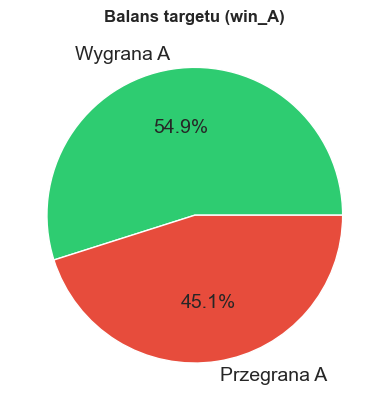

In [75]:
print(df[TARGET].value_counts())
df[TARGET].value_counts().plot.pie(autopct="%1.1f%%", labels=["Wygrana A", "Przegrana A"], colors=["#2ECC71", "#E74C3C"], textprops={"fontsize": 14})
plt.ylabel("")
plt.title("Balans targetu (win_A)", fontweight="bold")
plt.show()

PRZEWAGA GOSPODARZY (HOME ADVANTAGE)
  Ogólny win rate gospodarzy (A): 54.9%
  Test dwumianowy H0: win_rate = 0.5, p = 0.0000
  Wniosek: przewaga istotna statystycznie
  (975 wygranych na 1776 meczów)

  Win rate gospodarzy wg sezonu:
           Win rate  Mecze
season                    
2015/2016  0.588957    163
2016/2017  0.625641    195
2017/2018  0.574257    202
2018/2019  0.528662    157
2019/2020  0.519380    129
2020/2021  0.503106    161
2021/2022  0.560510    157
2022/2023  0.477941    136
2023/2024  0.537975    158
2024/2025  0.573248    157
2025/2026  0.509317    161

  Win rate poszczególnych drużyn jako gospodorz (A):
                          Win rate  Mecze
team_A                                   
Chemik Police             0.811688    154
Developres Rzeszów        0.783951    162
ŁKS Commercecon Łódź      0.735714    140
Budowlani Łódź            0.653595    153
Atom Trefl Sopot          0.607143     28
Muszynianka Muszyna       0.585366     41
BKS Bielsko-Biała       

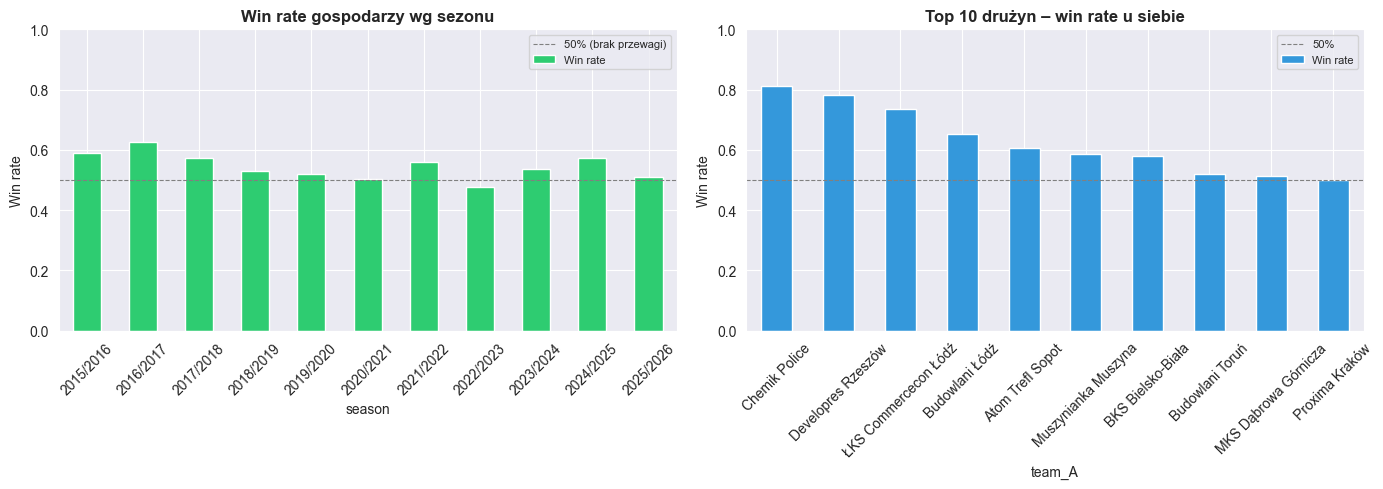

In [76]:
# === Analiza przewagi gospodarzy ===
print("=" * 65)
print("PRZEWAGA GOSPODARZY (HOME ADVANTAGE)")
print("=" * 65)

home_win_rate = df["win_A"].mean()
print(f"  Ogólny win rate gospodarzy (A): {home_win_rate:.1%}")
from scipy.stats import binomtest
p_val = binomtest((df["win_A"] == 1).sum(), len(df), p=0.5).pvalue
print(f"  Test dwumianowy H0: win_rate = 0.5, p = {p_val:.4f}")
print(f"  Wniosek: {'przewaga istotna statystycznie' if p_val < 0.05 else 'brak podstaw do odrzucenia H0'}")
wins = (df["win_A"] == 1).sum()
print(f"  ({wins} wygranych na {len(df)} meczów)")
print()

# Wg sezonu
print("  Win rate gospodarzy wg sezonu:")
season_home = df.groupby("season")["win_A"].agg(["mean", "count"])
season_home.columns = ["Win rate", "Mecze"]
print(season_home.to_string())
print()

# Wg druzyny (gdy gra u siebie)
print("  Win rate poszczególnych drużyn jako gospodorz (A):")
team_home = df.groupby("team_A")["win_A"].agg(["mean", "count"]).sort_values("mean", ascending=False)
team_home.columns = ["Win rate", "Mecze"]
print(team_home.to_string())
print()

# Wykres
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Win rate wg sezonu
season_home["Win rate"].plot.bar(ax=axes[0], color="#2ECC71", edgecolor="white")
axes[0].axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8, label="50% (brak przewagi)")
axes[0].set_title("Win rate gospodarzy wg sezonu", fontweight="bold")
axes[0].set_ylabel("Win rate")
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=45)

# Win rate wg druzyny (top 10)
top10 = team_home.head(10)
top10["Win rate"].plot.bar(ax=axes[1], color="#3498DB", edgecolor="white")
axes[1].axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8, label="50%")
axes[1].set_title("Top 10 drużyn – win rate u siebie", fontweight="bold")
axes[1].set_ylabel("Win rate")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(plot_path("eda", "home_advantage.png"), dpi=150, bbox_inches="tight")
plt.show()


zróżnicowanie miedzy sezonami jest dosc spore w sumie

PRZEWAGA GOSPODARZY W TIE-BREAKACH (5 SETÓW)
  Liczba meczów 5-setowych: 400

  Win rate gospodarzy w tie-breakach: 53.5%
  (214 wygranych na 400 meczów)

  Dla porównania – win rate gospodarzy ogólnie: 54.9%
  Różnica (tie-break vs ogółem): -1.4%

  Win rate gospodarzy w tie-breakach wg sezonu:
           Win rate  Mecze
season                    
2015/2016  0.666667     30
2016/2017  0.700000     50
2017/2018  0.479167     48
2018/2019  0.463415     41
2019/2020  0.480000     25
2020/2021  0.384615     39
2021/2022  0.564103     39
2022/2023  0.538462     26
2023/2024  0.406250     32
2024/2025  0.631579     38
2025/2026  0.531250     32

  Porównanie win rate gospodarzy:
                     Win rate gospodarzy  Liczba meczów
3-4 sety                        0.553052           1376
5 setów (tie-break)             0.535000            400



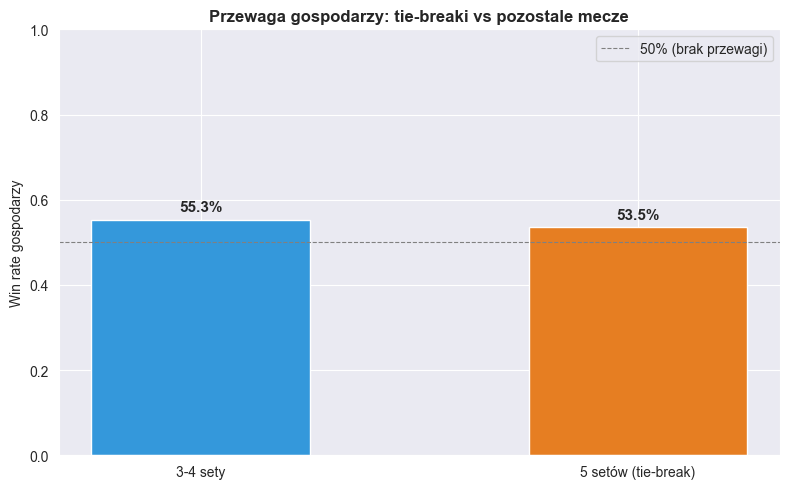

In [77]:
# === Przewaga gospodarzy w tie-breakach (5 set) ===
print("=" * 65)
print("PRZEWAGA GOSPODARZY W TIE-BREAKACH (5 SETÓW)")
print("=" * 65)

df_tb = df[df["number_of_sets"] == 5].copy()
print(f"  Liczba meczów 5-setowych: {len(df_tb)}")
print()

tb_win_rate = df_tb["win_A"].mean()
print(f"  Win rate gospodarzy w tie-breakach: {tb_win_rate:.1%}")
wins_tb = (df_tb["win_A"] == 1).sum()
print(f"  ({wins_tb} wygranych na {len(df_tb)} meczów)")
print()

all_home = df["win_A"].mean()
print(f"  Dla porównania – win rate gospodarzy ogólnie: {all_home:.1%}")
print(f"  Różnica (tie-break vs ogółem): {tb_win_rate - all_home:+.1%}")
print()

# Wg sezonu
print("  Win rate gospodarzy w tie-breakach wg sezonu:")
tb_season = df_tb.groupby("season")["win_A"].agg(["mean", "count"])
tb_season.columns = ["Win rate", "Mecze"]
print(tb_season.to_string())
print()

# Porównanie: tie-break vs pozostale mecze
df["czy_tiebreak"] = (df["number_of_sets"] == 5).astype(int)
comparison = df.groupby("czy_tiebreak")["win_A"].agg(["mean", "count"])
comparison.index = ["3-4 sety", "5 setów (tie-break)"]
comparison.columns = ["Win rate gospodarzy", "Liczba meczów"]
print("  Porównanie win rate gospodarzy:")
print(comparison.to_string())
print()

# Czyscimy pomocnicza kolumne
df.drop(columns=["czy_tiebreak"], inplace=True, errors="ignore")

# Wykres porównawczy
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(["3-4 sety", "5 setów (tie-break)"], comparison["Win rate gospodarzy"], 
        color=["#3498DB", "#E67E22"], edgecolor="white", width=0.5)
ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8, label="50% (brak przewagi)")
ax.set_ylim(0, 1)
ax.set_ylabel("Win rate gospodarzy")
ax.set_title("Przewaga gospodarzy: tie-breaki vs pozostale mecze", fontweight="bold")
for bar, val in zip(bars, comparison["Win rate gospodarzy"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.1%}", 
            ha="center", fontsize=11, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(plot_path("eda", "home_advantage_tiebreak.png"), dpi=150, bbox_inches="tight")
plt.show()


target jest mniej więcej zbalansowany, porownanie pokazuje ze w tiebreakach to nie ma wiekszej roznicy czy sie gra u siebie

### 3.1.Braki danych

Sprawdzamy, które cechy mają braki i ile wierszy zostanie odrzuconych przez `dropna` w modelu.

In [78]:
nan_counts = df.isna().sum()
nan_table = (
    nan_counts[nan_counts > 0]
    .rename("Braki")
    .reset_index()
    .rename(columns={"index": "Kolumna"})
    .sort_values("Braki", ascending=False)
)

X_check, y_check = prepare_xy(df, FEATURES_ALL)
completeness_summary = pd.DataFrame(
    {
        "Wskaźnik": [
            "Łącznie wierszy",
            "Po dropna (wszystkie cechy)",
            "Utracone wiersze",
            "Utracony odsetek",
        ],
        "Wartość": [
            len(df),
            len(X_check),
            len(df) - len(X_check),
            f"{((len(df) - len(X_check)) / len(df) * 100):.1f}%",
        ],
    }
)

if nan_table.empty:
    print("Wszystkie cechy kompletne")
else:
    display(nan_table)

display(completeness_summary)


Wszystkie cechy kompletne


,Wskaźnik,Wartość
0,Łącznie wierszy,1776
1,Po dropna (wszystkie cechy),1776
2,Utracone wiersze,0
3,Utracony odsetek,0.0%


zaczynamy od zestawu 12 cech z roznych aspektow gry i szukamy kombinacji o najmniejszej multikolinearnosci

## 4) Selekcja cech

Najpierw usuwamy silnie skorelowane cechy, żeby uniknąć multikolinearności. Potem na wybranych robimy EDA.

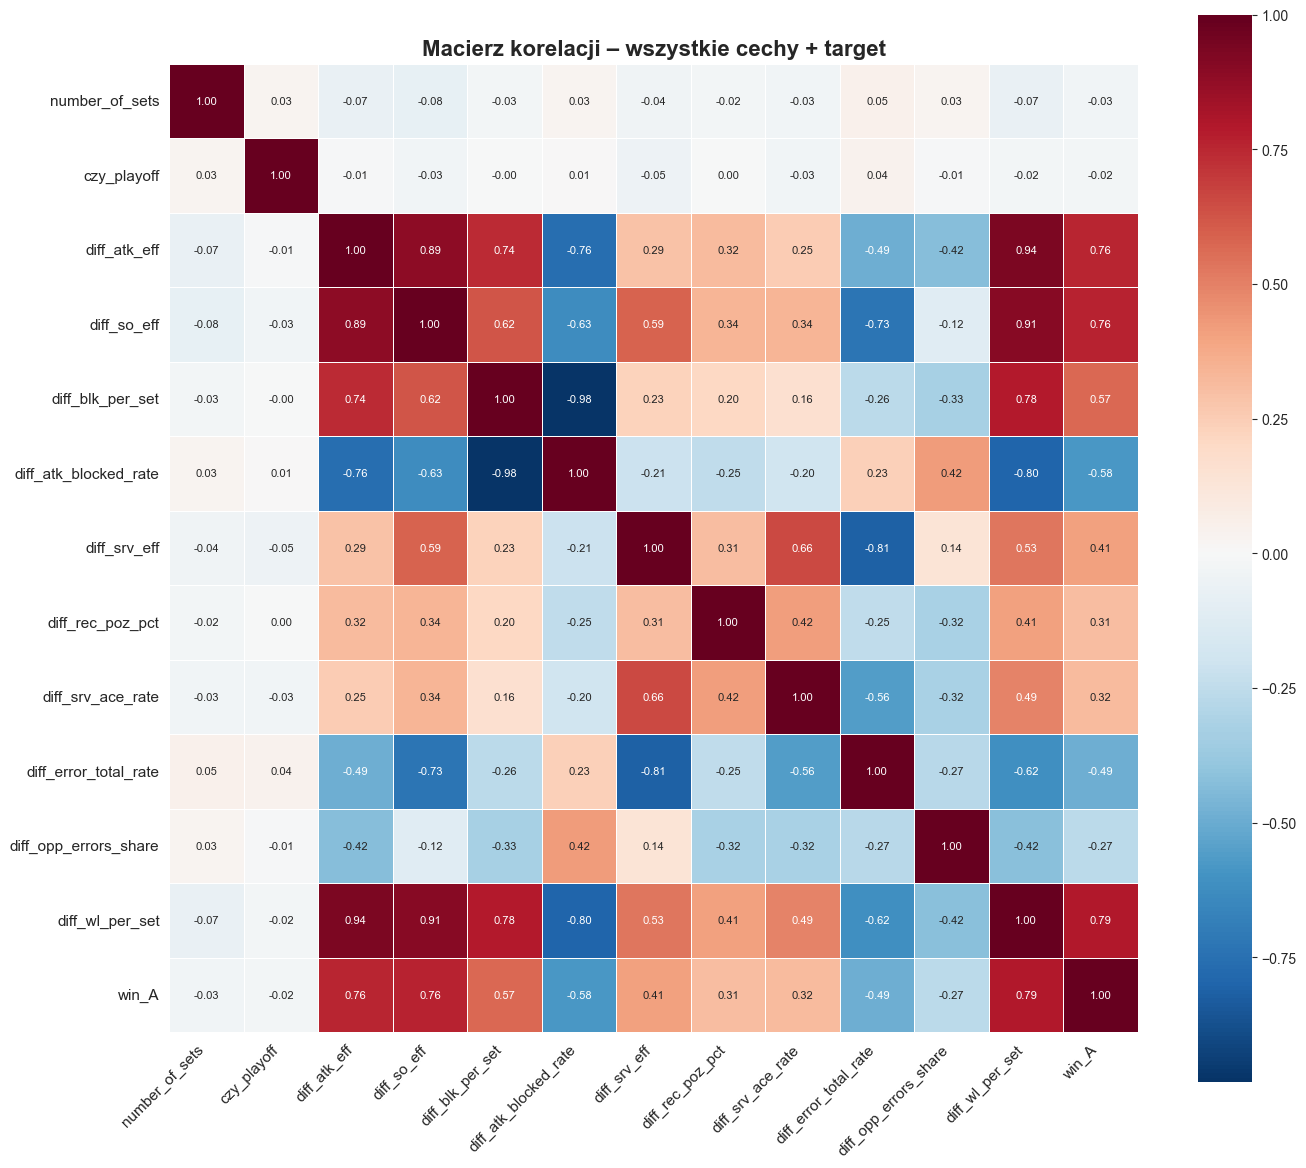

In [79]:
corr_cols = FEATURES_ALL + [TARGET]
corr = df[corr_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="RdBu_r",
    center=0,
    annot=True,
    annot_kws={"size": 8},
    fmt=".2f",
    linewidths=0.5,
    square=True,
)

plt.title("Macierz korelacji – wszystkie cechy + target", fontsize=16, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig(plot_path("eda", "heatmap_korelacji_z_targetem.png"), dpi=150, bbox_inches="tight")
plt.show()


In [80]:
target_corr = (
    df[FEATURES_ALL + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .to_frame(name="Korelacja")
)
target_corr["|Korelacja|"] = target_corr["Korelacja"].abs()
target_corr = target_corr.sort_values("|Korelacja|", ascending=False).reset_index()
target_corr = target_corr.rename(columns={"index": "Cecha"})

display(target_corr[["Cecha", "Korelacja"]].round(4))


,Cecha,Korelacja
0,diff_wl_per_set,0.7950
1,diff_so_eff,0.7614
2,diff_atk_eff,0.7562
3,diff_atk_blocked_rate,-0.5804
4,diff_blk_per_set,0.5737
5,diff_error_total_rate,-0.4892
6,diff_srv_eff,0.4087
7,diff_srv_ace_rate,0.3160
8,diff_rec_poz_pct,0.3083
9,diff_opp_errors_share,-0.2685


In [81]:
corr_pred = df[FEATURES_ALL].corr()
pairs = []
for i, col1 in enumerate(corr_pred.columns):
    for j, col2 in enumerate(corr_pred.columns):
        if i < j:
            val = corr_pred.loc[col1, col2]
            pairs.append((col1, col2, val))
pairs_df = pd.DataFrame(pairs, columns=["Cecha 1", "Cecha 2", "r"])
pairs_df["|r|"] = pairs_df["r"].abs()
pairs_df = pairs_df.sort_values("|r|", ascending=False)
display(pairs_df[pairs_df["|r|"] > 0.70].round(4))



,Cecha 1,Cecha 2,r,|r|
38,diff_blk_per_set,diff_atk_blocked_rate,-0.9806,0.9806
29,diff_atk_eff,diff_wl_per_set,0.9361,0.9361
37,diff_so_eff,diff_wl_per_set,0.9058,0.9058
21,diff_atk_eff,diff_so_eff,0.8893,0.8893
53,diff_srv_eff,diff_error_total_rate,-0.8110,0.8110
50,diff_atk_blocked_rate,diff_wl_per_set,-0.8014,0.8014
44,diff_blk_per_set,diff_wl_per_set,0.7846,0.7846
23,diff_atk_eff,diff_atk_blocked_rate,-0.7595,0.7595
22,diff_atk_eff,diff_blk_per_set,0.7401,0.7401
35,diff_so_eff,diff_error_total_rate,-0.7288,0.7288


### 4.1. Wnioski z analizy korelacji (Redukcja wymiarowości)

Z powyższej analizy par o wysokiej korelacji (|r| > 0.70) płyną jasne wnioski statystyczne, które pokrywają się z logiką gry w siatkówkę:
1. **Atak a Side-out:** Zmienna `diff_so_eff` (skuteczność wyjścia z przyjęcia) jest drastycznie skorelowana z `diff_atk_eff` (efektywnością ataku). Wynika to z faktu, że większość akcji side-out kończy się atakiem. Pozostawienie obu zmiennych doprowadziłoby do współliniowości. Wybieramy `diff_atk_eff` jako miarę bardziej uniwersalną (obejmuje też kontrataki).
2. **Kaskada błędów:** Zmienne takie jak `diff_error_total_rate` są sumą innych błędów (w ataku, na zagrywce). Nie możemy w jednym modelu umieścić szczegółowych wskaźników efektywności (które już zawierają w sobie kary za błędy) oraz ogólnego wskaźnika błędów.
3. **Punkty a wskaźniki per set:** Aby zniwelować różnice między krótkimi (3 sety) a długimi (5 setów) meczami, opieramy się na wartościach uśrednionych (`per_set`) lub procentowych (`rate`, `eff`), odrzucając statystyki absolutne (jak łączna liczba bloków).

### 4.2. Definicja Zestawów Cech (Feature Sets)

Opierając się na powyższej filtracji statystycznej oraz wiedzy domenowej o siatkówce, zamiast szukać jednego "idealnego" modelu, celowo definiujemy **cztery różne ujęcia analityczne**. Pozwoli to sprawdzić stabilność wniosków i zbadać grę z różnych perspektyw:

* **Model 1 (Ekspercki):** Nasz model główny. Reprezentuje "siatkarskie DNA". Zawiera po jednym, najlepszym wskaźniku z każdego elementu rzemiosła (Atak, Blok, Serwis, Przyjęcie, darmowe punkty z błędów rywala). Zbudowany tak, by minimalizować VIF.
* **Model 2 (Agregatowy):** Ekstremalnie uproszczony. Sprawdza, czy wystarczy wiedzieć, kto zdobywał więcej punktów per set (`diff_wl_per_set`) i kto dostawał więcej darmowych punktów, by opisać mecz.
* **Model 3 (Dyscyplina i Presja):** Skupia się na "ciemnej stronie gry". Wyklucza czystą jakość ataku na rzecz miar takich jak błędy własne (`error_total_rate`) i bycie zatrzymanym przez blok rywala (`atk_blocked_rate`).
* **Model 4 (Full - Baseline):** Model kontrolny, do którego "wrzucono" wszystkie 12 statystyk. Służy wyłącznie do celów diagnostycznych, by matematycznie udowodnić (poprzez wysoki VIF), że nadmiar danych szkodzi interpretacji. Zmienne kontekstowe (`czy_playoff`, `number_of_sets`) dodawane są do każdego modelu jako zmienne kontrolne.

In [82]:
SET1_FEATURES = [
    "diff_atk_eff",
    "diff_blk_per_set",
    "diff_srv_eff",
    "diff_rec_poz_pct",
    "diff_opp_errors_share",
    "number_of_sets",
    "czy_playoff",
]

SET2_FEATURES = [
    "diff_wl_per_set",
    "diff_opp_errors_share",
    "number_of_sets",
    "czy_playoff",
]

SET3_FEATURES = [
    "diff_atk_blocked_rate",
    "diff_error_total_rate",
    "diff_rec_poz_pct",
    "diff_srv_ace_rate",
    "number_of_sets",
    "czy_playoff",
]

SET4_FEATURES = [
    "number_of_sets",
    "czy_playoff",
    "diff_atk_eff",
    "diff_so_eff",
    "diff_blk_per_set",
    "diff_atk_blocked_rate",
    "diff_srv_eff",
    "diff_rec_poz_pct",
    "diff_srv_ace_rate",
    "diff_error_total_rate",
    "diff_opp_errors_share",
    "diff_wl_per_set",
]

feature_sets_table = pd.DataFrame(
    [
        {"Model": "Model 1 – Ekspercki", "Liczba cech": len(SET1_FEATURES), "Cechy": ", ".join(SET1_FEATURES)},
        {"Model": "Model 2 – Agregatowy", "Liczba cech": len(SET2_FEATURES), "Cechy": ", ".join(SET2_FEATURES)},
        {"Model": "Model 3 – Dyscyplina", "Liczba cech": len(SET3_FEATURES), "Cechy": ", ".join(SET3_FEATURES)},
        {"Model": "Model 4 – Full", "Liczba cech": len(SET4_FEATURES), "Cechy": ", ".join(SET4_FEATURES)},
    ]
)

display(feature_sets_table)


,Model,Liczba cech,Cechy
0,Model 1 – Ekspercki,7,"diff_atk_eff, diff_blk_per_set, diff_srv_eff, ..."
1,Model 2 – Agregatowy,4,"diff_wl_per_set, diff_opp_errors_share, number..."
2,Model 3 – Dyscyplina,6,"diff_atk_blocked_rate, diff_error_total_rate, ..."
3,Model 4 – Full,12,"number_of_sets, czy_playoff, diff_atk_eff, dif..."


,avg_diff_atk_eff,avg_diff_blk_per_set,avg_diff_srv_eff,avg_diff_rec_poz_pct,avg_num_sets,avg_czy_playoff,avg_diff_opp_errors_share,win_rate,matches
team_A,,,,,,,,,
Chemik Police,0.1172,0.6367,0.0278,6.0455,3.5909,0.1948,-0.0264,0.8117,154
Developres Rzeszów,0.1011,0.5910,0.0237,2.6296,3.7469,0.2346,-0.0253,0.7840,162
ŁKS Commercecon Łódź,0.0751,0.5070,0.0093,-1.0357,3.7643,0.2000,-0.0130,0.7357,140
Budowlani Łódź,0.0719,0.6880,0.0158,2.6013,3.7059,0.1961,-0.0186,0.6536,153
Atom Trefl Sopot,0.0272,0.2887,0.0166,4.0357,3.9643,0.1429,0.0150,0.6071,28
Muszynianka Muszyna,0.0155,-0.0028,0.0011,0.5854,4.0000,0.0976,0.0103,0.5854,41
BKS Bielsko-Biała,0.0223,0.2872,-0.0040,2.4662,3.8176,0.1622,-0.0239,0.5811,148
Budowlani Toruń,-0.0229,0.4685,0.0102,-2.2222,3.7407,0.0370,0.0494,0.5185,27
MKS Dąbrowa Górnicza,0.0058,-0.4983,-0.0038,0.1795,3.8718,0.0769,-0.0110,0.5128,39


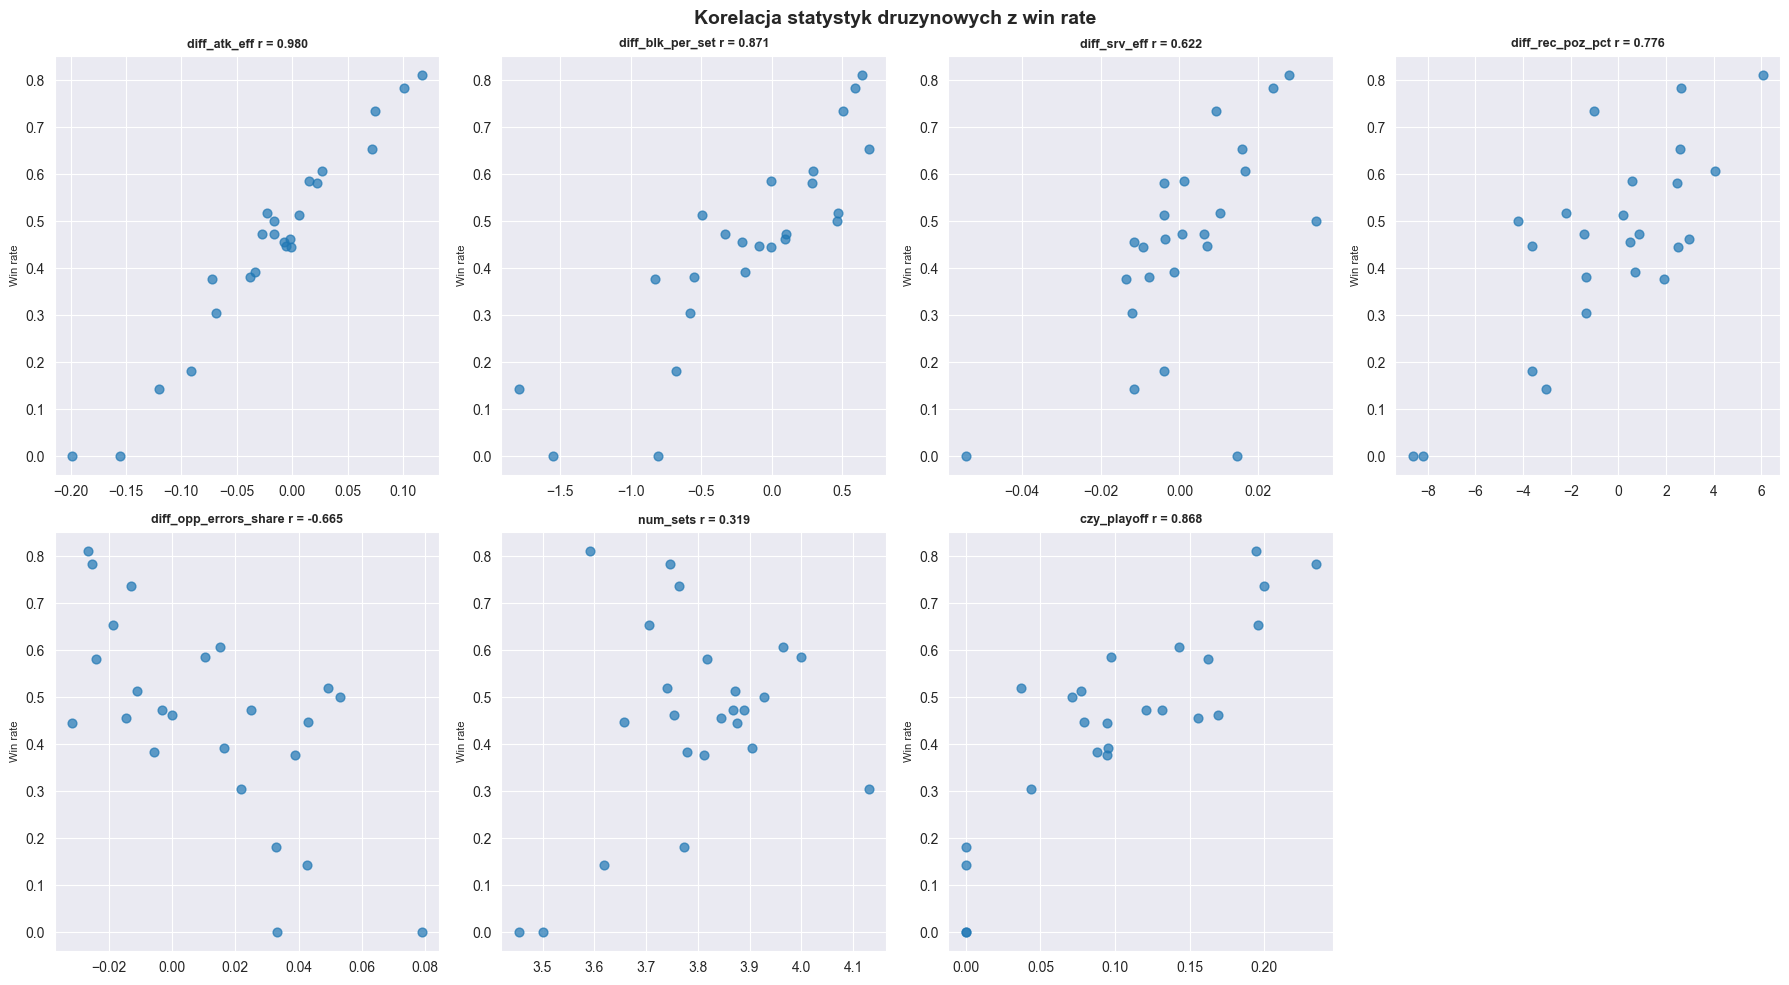

In [83]:
# === Statystyki druzynowe z originalnego df ===


# Uzywamy df bezposrednio, zamiast df_profiles_base, zeby miec wszystkie diff_* kolumny
team_stats = (
    df.groupby("team_A")
    .agg(
        avg_diff_atk_eff=("diff_atk_eff", "mean"),
        avg_diff_blk_per_set=("diff_blk_per_set", "mean"),
        avg_diff_srv_eff=("diff_srv_eff", "mean"),
        avg_diff_rec_poz_pct=("diff_rec_poz_pct", "mean"),
        avg_num_sets=("number_of_sets", "mean"),
        avg_czy_playoff=("czy_playoff", "mean"),
        avg_diff_opp_errors_share=("diff_opp_errors_share", "mean"),

        win_rate=("win_A", "mean"),
        matches=("win_A", "count"),
    )
    .sort_values("win_rate", ascending=False)
)

corr_atk = team_stats["avg_diff_atk_eff"].corr(team_stats["win_rate"])
corr_blk = team_stats["avg_diff_blk_per_set"].corr(team_stats["win_rate"])
display(team_stats.head(10).round(4))

# === Scatter plot — wszystkie cechy SET1 vs win rate ===
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
all_feats_team = ["diff_atk_eff", "diff_blk_per_set", "diff_srv_eff",
                  "diff_rec_poz_pct", "diff_opp_errors_share",
                  "num_sets", "czy_playoff"]
for ax, feat in zip(axes.flatten(), all_feats_team):
    col = f"avg_{feat}"
    if col in team_stats.columns:
        team_stats.plot.scatter(x=col, y="win_rate", ax=ax, alpha=0.7, s=40)
        corr_val = team_stats[col].corr(team_stats["win_rate"])
        ax.set_title(f'{feat} r = {corr_val:.3f}', fontsize=9, fontweight='bold')
        ax.set_xlabel("")
        ax.set_ylabel("Win rate", fontsize=8)
        
for i_ax in range(len(all_feats_team), len(axes.flatten())):
    axes.flatten()[i_ax].set_visible(False)

plt.suptitle("Korelacja statystyk druzynowych z win rate", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(plot_path("eda", "team_stats_vs_winrate.png"), dpi=150, bbox_inches="tight")
plt.show()


ROZKLAD CECH WG WYNIKU MECZU


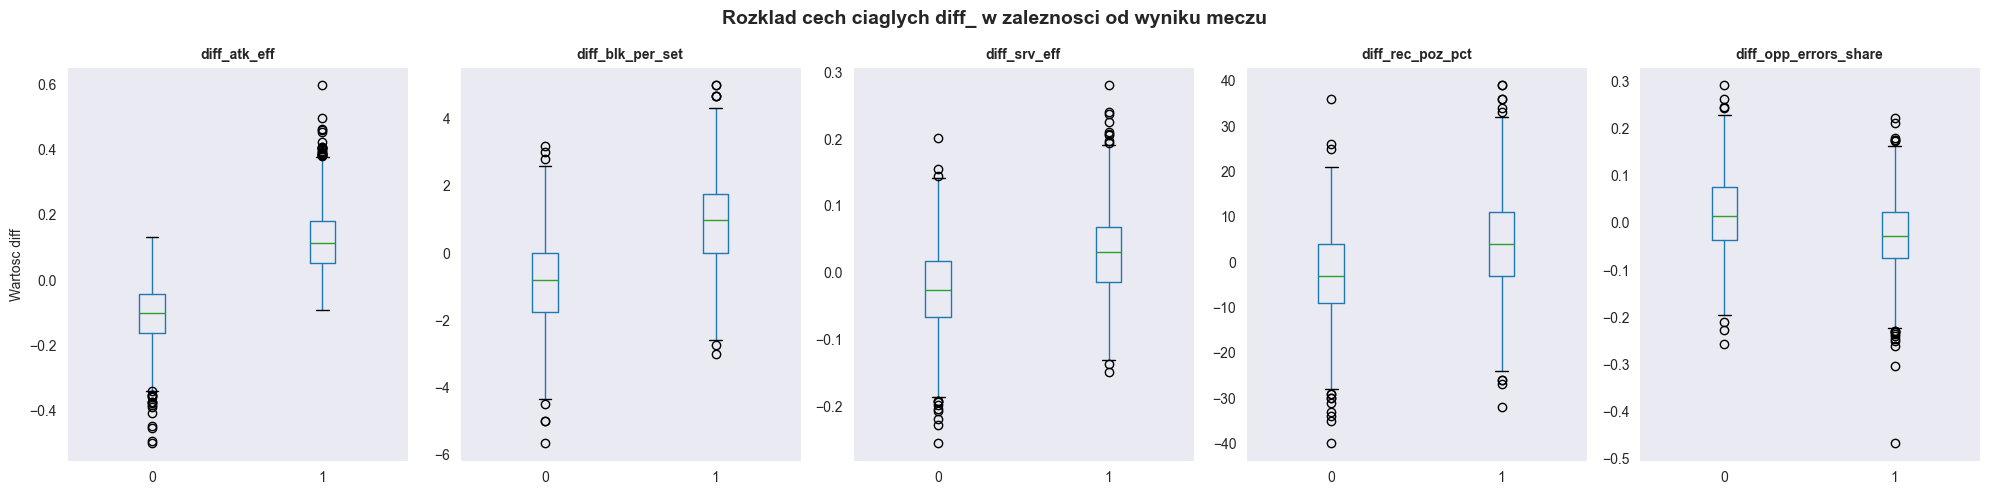


LICZBA SETOW A WYNIK MECZU


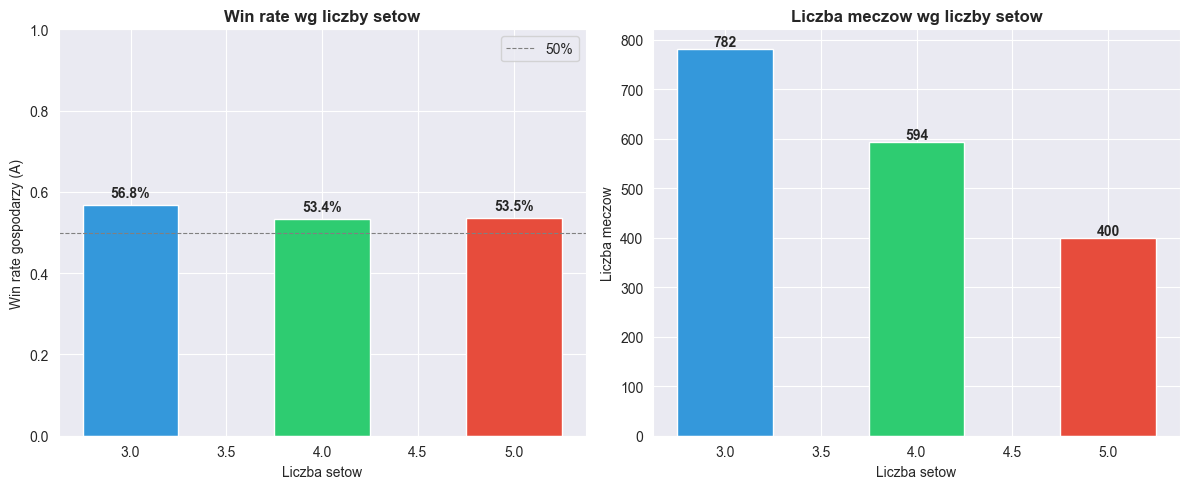


PLAYOFF A WYNIK MECZU


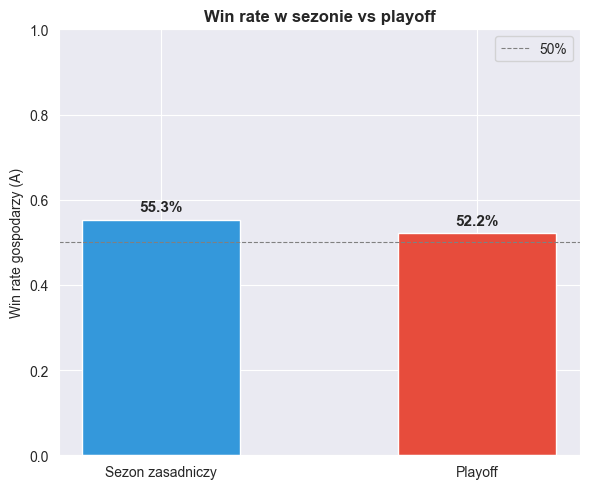

  Mecze w sezonie: 1525
  Mecze w playoff: 251


In [84]:
# === Box ploty diff_ vs win/loss (z osobna prezentacja dla number_of_sets i czy_playoff) ===
print("=" * 70)
print("ROZKLAD CECH WG WYNIKU MECZU")
print("=" * 70)

# Cechy ciagle — box ploty
continuous_feats = ["diff_atk_eff", "diff_blk_per_set", "diff_srv_eff", 
                    "diff_rec_poz_pct", "diff_opp_errors_share"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, feat in zip(axes.flatten(), continuous_feats):
    df.boxplot(column=feat, by=TARGET, ax=ax, grid=False)
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Wartosc diff" if feat == continuous_feats[0] else "")

plt.suptitle("Rozklad cech ciaglych diff_ w zaleznosci od wyniku meczu", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(plot_path("eda", "boxplot_diff_vs_win.png"), dpi=150, bbox_inches="tight")
plt.show()

# number_of_sets — rozklad wygranych wg liczby setow
print("\n" + "=" * 70)
print("LICZBA SETOW A WYNIK MECZU")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Win rate wedlug liczby setow
sets_winrate = df.groupby("number_of_sets")["win_A"].mean()
sets_count = df.groupby("number_of_sets")["win_A"].count()

axes[0].bar(sets_winrate.index, sets_winrate.values, 
           color=["#3498DB", "#2ECC71", "#E74C3C"], edgecolor="white", width=0.5)
axes[0].axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8, label="50%")
axes[0].set_xlabel("Liczba setow")
axes[0].set_ylabel("Win rate gospodarzy (A)")
axes[0].set_title("Win rate wg liczby setow", fontweight="bold")
axes[0].set_ylim(0, 1)
for x, y in zip(sets_winrate.index, sets_winrate.values):
    axes[0].text(x, y + 0.02, f"{y:.1%}", ha="center", fontsize=10, fontweight="bold")
axes[0].legend()

# Licznosc meczow wedlug liczby setow
axes[1].bar(sets_count.index, sets_count.values, 
           color=["#3498DB", "#2ECC71", "#E74C3C"], edgecolor="white", width=0.5)
axes[1].set_xlabel("Liczba setow")
axes[1].set_ylabel("Liczba meczow")
axes[1].set_title("Liczba meczow wg liczby setow", fontweight="bold")
for x, y in zip(sets_count.index, sets_count.values):
    axes[1].text(x, y + 5, str(y), ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(plot_path("eda", "sets_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

# czy_playoff — porownanie win rate
print("\n" + "=" * 70)
print("PLAYOFF A WYNIK MECZU")
print("=" * 70)

playoff_winrate = df.groupby("czy_playoff")["win_A"].mean()
playoff_count = df.groupby("czy_playoff")["win_A"].count()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(["Sezon zasadniczy", "Playoff"], playoff_winrate.values,
        color=["#3498DB", "#E74C3C"], edgecolor="white", width=0.5)
ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8, label="50%")
ax.set_ylim(0, 1)
ax.set_ylabel("Win rate gospodarzy (A)")
ax.set_title("Win rate w sezonie vs playoff", fontweight="bold")
for bar, val in zip(bars, playoff_winrate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.1%}", ha="center", fontsize=11, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(plot_path("eda", "playoff_winrate.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"  Mecze w sezonie: {playoff_count.values[0]}")
print(f"  Mecze w playoff: {playoff_count.values[1]}")


=== Prawdziwa Przewaga Hali (Top i Flop) ===


,Drużyna,Mecze,Wygrane (Suma),Win Rate (Dom),Win Rate (Wyjazd),Delta (Dom - Wyjazd),Udział wygranych domowych
3,Budowlani Toruń,53,20,0.519,0.231,0.288,0.700
13,Muszynianka Muszyna,82,37,0.585,0.317,0.268,0.649
8,KSZO Ostrowiec,108,26,0.377,0.109,0.268,0.769
19,Stal Mielec,78,29,0.474,0.275,0.199,0.621
10,Legionovia,182,73,0.473,0.330,0.143,0.589
1,Atom Trefl Sopot,55,30,0.607,0.481,0.126,0.567
14,PTPS Piła,150,58,0.447,0.324,0.123,0.586
11,MKS Dąbrowa Górnicza,80,36,0.513,0.390,0.123,0.556
21,Volley Wrocław,275,106,0.445,0.326,0.119,0.575
2,BKS Bielsko-Biała,297,158,0.581,0.483,0.098,0.544


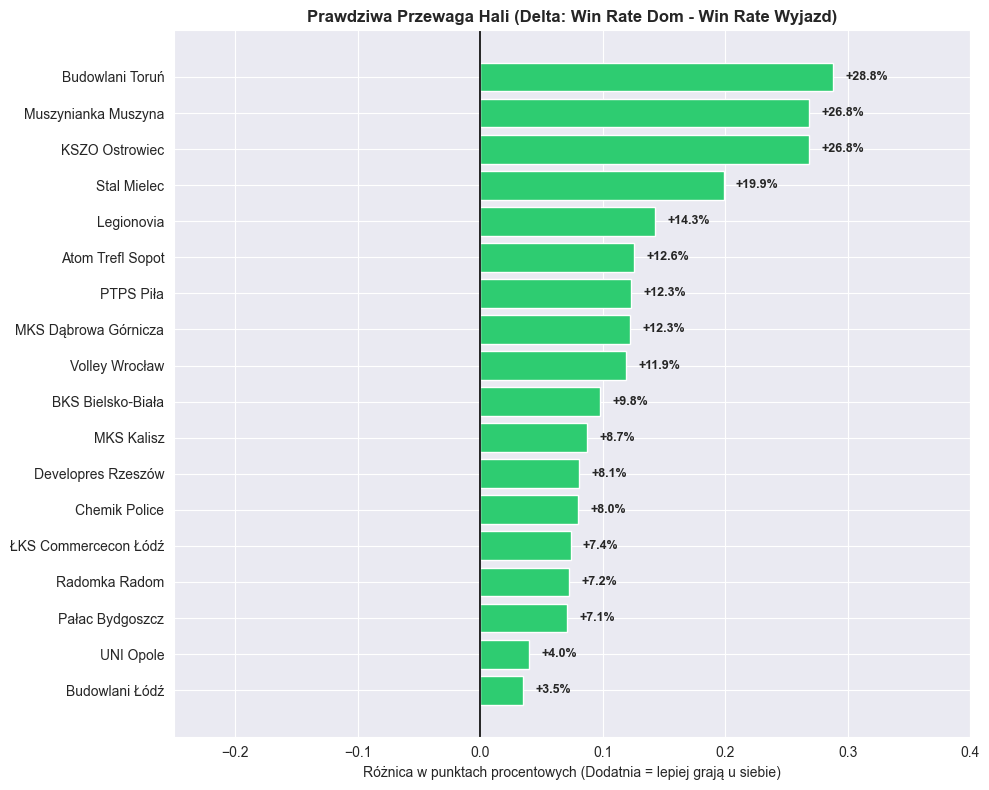

In [106]:
# === PRAWDZIWA PRZEWAGA GOSPODARZA (Oczyszczona z ogólnej siły drużyny) ===

teams = sorted(set(df["team_A"]).union(set(df["team_B"])))
ha_records = []

for team in teams:
    # Statystyki domowe (team gra jako A)
    home_matches = df[df["team_A"] == team]
    home_games = len(home_matches)
    home_wins = home_matches["win_A"].sum()

    # Statystyki wyjazdowe (team gra jako B - wygrywa gdy win_A == 0)
    away_matches = df[df["team_B"] == team]
    away_games = len(away_matches)
    away_wins = (away_matches["win_A"] == 0).sum()

    total_games = home_games + away_games
    total_wins = home_wins + away_wins

    if total_games > 0 and total_wins > 0: # Odrzucamy drużyny bez zwycięstw
        home_win_rate = home_wins / home_games if home_games > 0 else 0
        away_win_rate = away_wins / away_games if away_games > 0 else 0

        ha_records.append({
            "Drużyna": team,
            "Mecze": total_games,
            "Wygrane (Suma)": total_wins,
            "Win Rate (Dom)": home_win_rate,
            "Win Rate (Wyjazd)": away_win_rate,
            "Delta (Dom - Wyjazd)": home_win_rate - away_win_rate,
            "Udział wygranych domowych": home_wins / total_wins
        })

df_ha = pd.DataFrame(ha_records)

# Filtr: Bierzemy pod uwagę tylko drużyny, które wygrały w lidze łącznie minimum 20 meczów
# (żeby uniknąć szumu statystycznego, np. drużyny, która wygrała 1 mecz u siebie i 0 na wyjeździe)
df_ha = df_ha[df_ha["Wygrane (Suma)"] >= 20].copy()

# Sortujemy po prawdziwej przewadze hali (Delta)
df_ha = df_ha.sort_values("Delta (Dom - Wyjazd)", ascending=True)

# Wyświetlamy tabelę z wynikami
print("=== Prawdziwa Przewaga Hali (Top i Flop) ===")
display(df_ha.sort_values("Delta (Dom - Wyjazd)", ascending=False).head(10).round(3))

# --- GENEROWANIE WYKRESU ---
plt.figure(figsize=(10, 8))
colors = ['#2ECC71' if val > 0 else '#E74C3C' for val in df_ha["Delta (Dom - Wyjazd)"]]

bars = plt.barh(df_ha["Drużyna"], df_ha["Delta (Dom - Wyjazd)"], color=colors, edgecolor="white")
plt.axvline(x=0, color='black', linewidth=1.2)
plt.title("Prawdziwa Przewaga Hali (Delta: Win Rate Dom - Win Rate Wyjazd)", fontweight="bold")
plt.xlabel("Różnica w punktach procentowych (Dodatnia = lepiej grają u siebie)")

# Dodanie wartości na słupkach
for bar, val in zip(bars, df_ha["Delta (Dom - Wyjazd)"]):
    x_pos = bar.get_width()
    ha = 'left' if x_pos > 0 else 'right'
    offset = 0.01 if x_pos > 0 else -0.01
    plt.text(x_pos + offset, bar.get_y() + bar.get_height()/2, f"{val:+.1%}",
             va='center', ha=ha, fontsize=9, fontweight='bold')

plt.xlim(-0.25, 0.4) # Dostosuj oś X w razie potrzeby
plt.tight_layout()
plt.savefig(plot_path("eda", "true_home_advantage.png"), dpi=150, bbox_inches="tight")
plt.show()

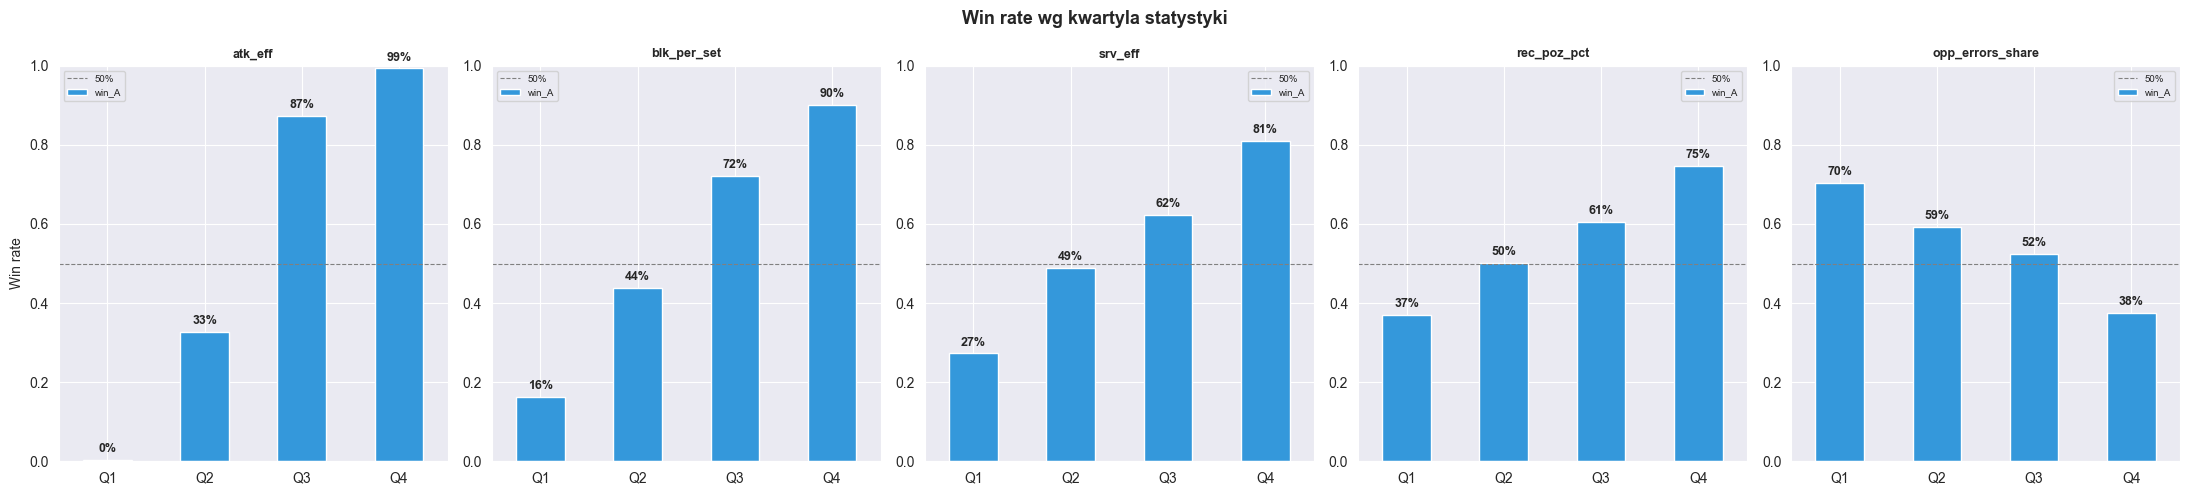

In [85]:
# === Win rate wedlug kwartyla statystyki ===
feats_q = ["diff_atk_eff", "diff_blk_per_set", "diff_srv_eff", "diff_rec_poz_pct", "diff_opp_errors_share"]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, feat in zip(axes, feats_q):
    df[f"{feat}_q"] = pd.qcut(df[feat], 4, labels=["Q1", "Q2", "Q3", "Q4"])
    wr = df.groupby(f"{feat}_q", observed=True)["win_A"].mean()
    wr.plot.bar(ax=ax, color="#3498DB", edgecolor="white")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="50%")
    ax.set_title(feat.replace("diff_", ""), fontsize=9, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.set_xlabel("")
    ax.set_ylabel("Win rate" if feat == feats_q[0] else "")
    ax.tick_params(axis="x", rotation=0)
    for bar, val in zip(ax.patches, wr.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.0%}", ha="center", fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)

plt.suptitle("Win rate wg kwartyla statystyki", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(plot_path("eda", "winrate_kwartyle.png"), dpi=150, bbox_inches="tight")
plt.show()

# Czyscimy pomocnicze kolumny
for feat in feats_q:
    df.drop(columns=[f"{feat}_q"], inplace=True, errors="ignore")


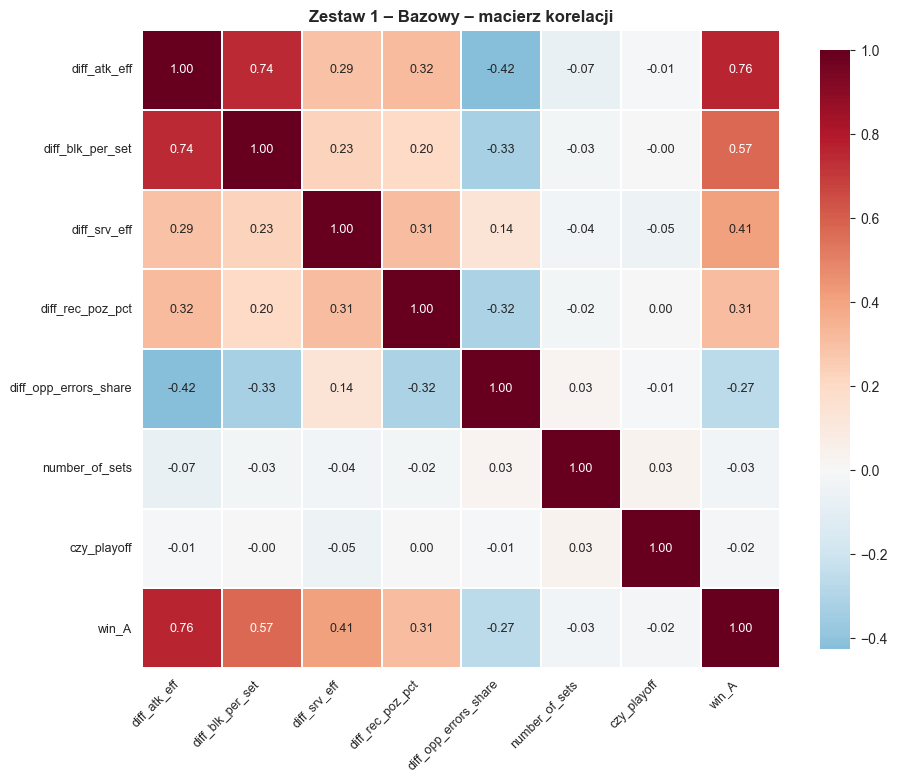

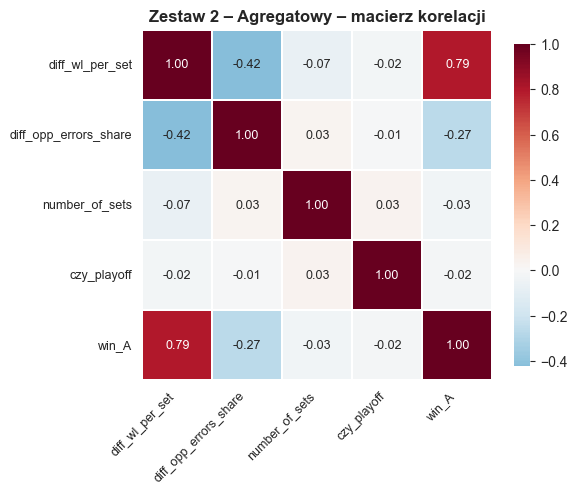

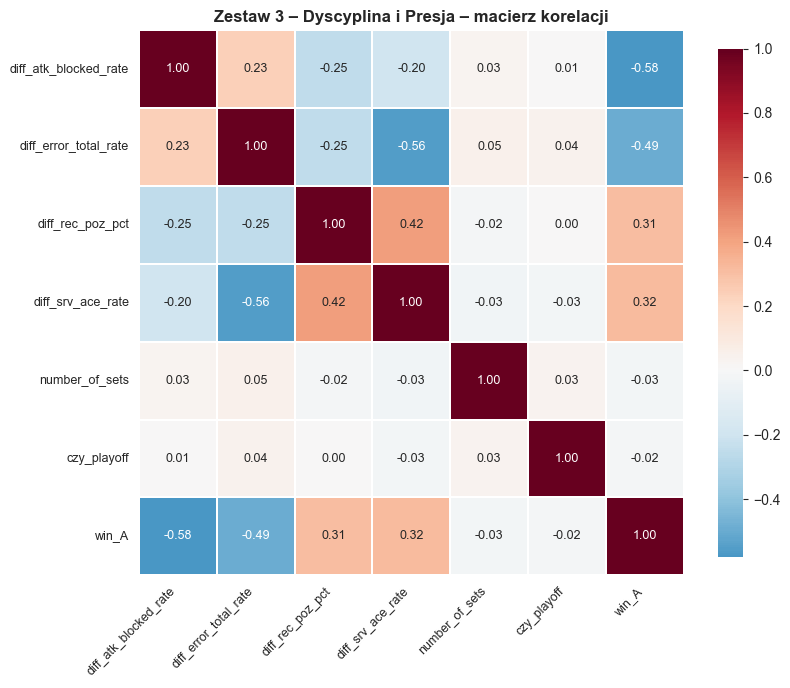

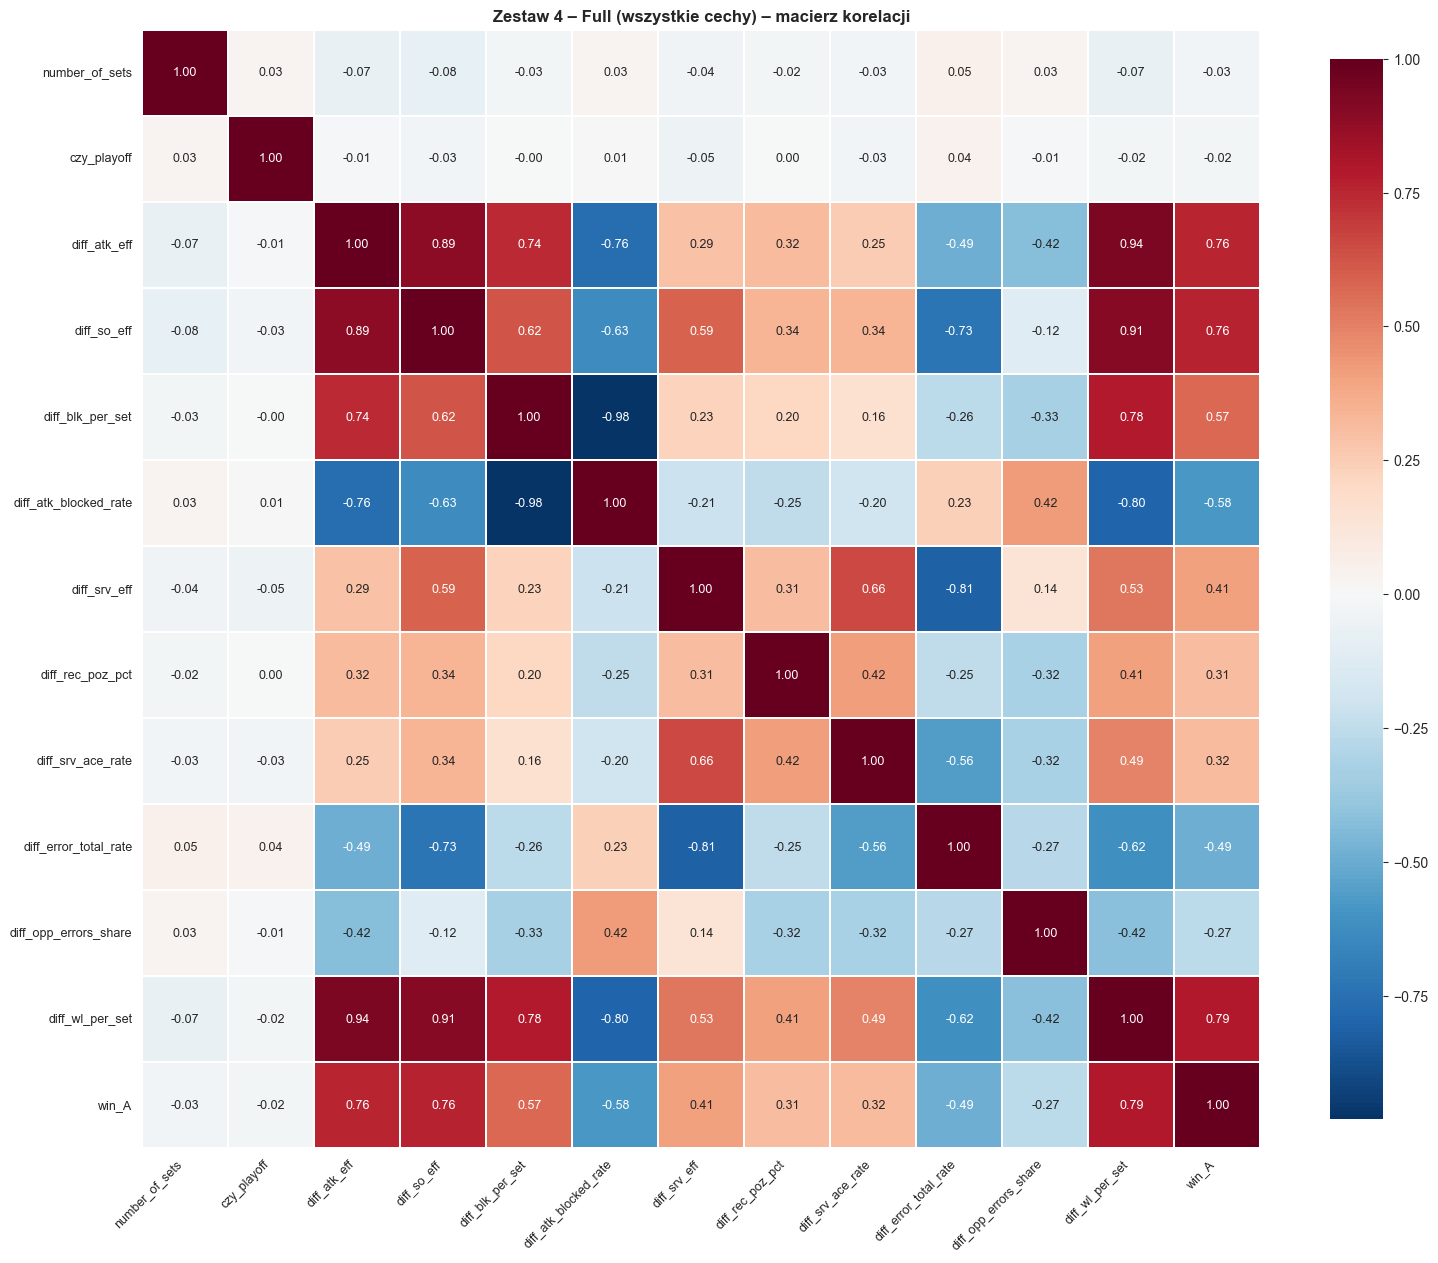

In [86]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

sets = [
    ("Zestaw 1 – Bazowy", SET1_FEATURES),
    ("Zestaw 2 – Agregatowy", SET2_FEATURES),
    ("Zestaw 3 – Dyscyplina i Presja", SET3_FEATURES),
    ("Zestaw 4 – Full (wszystkie cechy)", SET4_FEATURES),
]

for name, feats in sets:
    corr_cols = feats + [TARGET]
    corr = df[corr_cols].corr()

    plt.figure(figsize=(len(corr_cols) * 1.2, len(corr_cols) * 1.0))
    sns.heatmap(
        corr,
        cmap="RdBu_r",
        center=0,
        annot=True,
        annot_kws={"size": 9},
        fmt=".2f",
        linewidths=0.3,
        square=True,
        cbar_kws={"shrink": 0.9},
    )
    plt.title(f"{name} – macierz korelacji", fontsize=12, fontweight="bold")
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

    X_vif = df[feats].copy()
    for c in feats:
        X_vif[c] = pd.to_numeric(X_vif[c], errors="coerce")
    X_vif = X_vif.dropna()

    X_vif_const = add_constant(X_vif)
    vif_table = pd.DataFrame(
        {
            "Cecha": feats,
            "VIF": [
                variance_inflation_factor(X_vif_const.values, i + 1)
                for i in range(len(feats))
            ],
        }
    )
    vif_table["VIF"] = vif_table["VIF"].round(3)




In [87]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

models = [
    ("Model 1 – Ekspercki", SET1_FEATURES),
    ("Model 2 – Agregatowy", SET2_FEATURES),
    ("Model 3 – Dyscyplina", SET3_FEATURES),
    ("Model 4 – Full", SET4_FEATURES),
]

all_feats = []
for name, feats in models:
    for f in feats:
        if f not in all_feats:
            all_feats.append(f)

vif_results = {}
for name, feats in models:
    X_vif = df[feats].copy()
    for c in feats:
        X_vif[c] = pd.to_numeric(X_vif[c], errors="coerce")
    X_vif = X_vif.dropna()
    X_vif_const = add_constant(X_vif)
    vif_results[name] = {
        col: round(variance_inflation_factor(X_vif_const.values, j + 1), 3)
        for j, col in enumerate(feats)
    }

rows = []
for f in all_feats:
    row = {"Cecha": f}
    for name, feats in models:
        row[name] = vif_results[name].get(f)
    rows.append(row)

comparison = pd.DataFrame(rows)
summary = {"Cecha": "Średni VIF"}
for name, feats in models:
    vals = [vif_results[name][f] for f in feats]
    summary[name] = round(sum(vals) / len(vals), 3)
comparison = pd.concat([comparison, pd.DataFrame([summary])], ignore_index=True)

display(comparison)


,Cecha,Model 1 – Ekspercki,Model 2 – Agregatowy,Model 3 – Dyscyplina,Model 4 – Full
0,diff_atk_eff,2.639,NaN,NaN,43.692
1,diff_blk_per_set,2.228,NaN,NaN,52.705
2,diff_srv_eff,1.349,NaN,NaN,7.952
3,diff_rec_poz_pct,1.308,NaN,1.257,1.387
4,diff_opp_errors_share,1.483,1.219,NaN,14.260
5,number_of_sets,1.008,1.006,1.004,1.010
6,czy_playoff,1.004,1.002,1.003,1.005
7,diff_wl_per_set,NaN,1.224,NaN,101.664
8,diff_atk_blocked_rate,NaN,NaN,1.105,43.220
9,diff_error_total_rate,NaN,NaN,1.492,15.989


## 5) Regresja logistyczna i porównanie modeli

W tej części porównujemy cztery zestawy cech. Najpierw dopasowujemy modele
`Logit`, potem zestawiamy współczynniki i na końcu sprawdzamy prostą
walidację `train/test`.


In [88]:
import statsmodels.api as sm

models_def = [
    ("Model 1 – Ekspercki", SET1_FEATURES),
    ("Model 2 – Agregatowy", SET2_FEATURES),
    ("Model 3 – Dyscyplina", SET3_FEATURES),
    ("Model 4 – Full", SET4_FEATURES),
]

all_feats_logit = []
for name, feats in models_def:
    for f in feats:
        if f not in all_feats_logit:
            all_feats_logit.append(f)

results_store = {}
pseudo_r2 = {}
nobs_store = {}
fit_rows = []

for name, feats in models_def:
    X_log, y_log = prepare_xy(df, feats)
    X_log_const = sm.add_constant(X_log)
    result = sm.Logit(y_log, X_log_const).fit(disp=False, maxiter=100)

    results_store[name] = result
    pseudo_r2[name] = result.prsquared
    nobs_store[name] = int(result.nobs)
    fit_rows.append(
        {
            "Model": name,
            "Pseudo R2": result.prsquared,
            "Log-Likelihood": result.llf,
            "Liczba obserwacji": int(result.nobs),
        }
    )

display(pd.DataFrame(fit_rows).round(4))


,Model,Pseudo R2,Log-Likelihood,Liczba obserwacji
0,Model 1 – Ekspercki,0.7383,-319.9490,1776
1,Model 2 – Agregatowy,0.7325,-326.9589,1776
2,Model 3 – Dyscyplina,0.4914,-621.7618,1776
3,Model 4 – Full,0.7958,-249.5864,1776


In [89]:
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import RobustScaler

trained_sk_models = {}
scalers_store = {}
split_store = {}
validation_rows = []

for name, feats in models_def:
    X_eval, y_eval = prepare_xy(df, feats)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_eval, y_eval, test_size=0.2, random_state=42, stratify=y_eval
    )

    scaler = RobustScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    lr = LogisticRegression(C=1e15, max_iter=2000, random_state=42)
    lr.fit(X_tr_s, y_tr)

    scalers_store[name] = scaler
    trained_sk_models[name] = lr
    split_store[name] = {
        "X_tr": X_tr.copy(),
        "X_te": X_te.copy(),
        "y_tr": y_tr.copy(),
        "y_te": y_te.copy(),
        "X_tr_s": X_tr_s,
        "X_te_s": X_te_s,
    }

    y_pred = lr.predict(X_te_s)
    y_prob = lr.predict_proba(X_te_s)[:, 1]
    cm = confusion_matrix(y_te, y_pred)

    validation_rows.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_te, y_pred),
            "AUC": roc_auc_score(y_te, y_prob),
            "TN": cm[0, 0],
            "FP": cm[0, 1],
            "FN": cm[1, 0],
            "TP": cm[1, 1],
            "Pseudo R2 (pełne dane)": pseudo_r2[name],
            "N": nobs_store[name],
        }
    )

validation_df = pd.DataFrame(validation_rows).sort_values("Pseudo R2 (pełne dane)", ascending=False)
display(validation_df.round(4))

best_descriptive_model = validation_df.iloc[0]["Model"]
print(f"Najwyzsze Pseudo R-squared (model opisowy): {best_descriptive_model}")

X_tr1 = split_store["Model 1 – Ekspercki"]["X_tr"]
X_te1 = split_store["Model 1 – Ekspercki"]["X_te"]
y_tr1 = split_store["Model 1 – Ekspercki"]["y_tr"]
y_te1 = split_store["Model 1 – Ekspercki"]["y_te"]
X_tr1_s = split_store["Model 1 – Ekspercki"]["X_tr_s"]
X_te1_s = split_store["Model 1 – Ekspercki"]["X_te_s"]
scaler1 = scalers_store["Model 1 – Ekspercki"]
logit_mod1_clean = sm.Logit(y_tr1, sm.add_constant(X_tr1)).fit(disp=0)



,Model,Accuracy,AUC,TN,FP,FN,TP,Pseudo R2 (pełne dane),N
3,Model 4 – Full,0.9522,0.9930,152,9,8,187,0.7958,1776
0,Model 1 – Ekspercki,0.9466,0.9859,151,10,9,186,0.7383,1776
1,Model 2 – Agregatowy,0.9298,0.9841,149,12,13,182,0.7325,1776
2,Model 3 – Dyscyplina,0.8315,0.9157,133,28,32,163,0.4914,1776


Najwyzsze Pseudo R-squared (model opisowy): Model 4 – Full


In [90]:
# === TABELA WSPÓŁCZYNNIKÓW I ILORAZÓW SZANS — Model 1 (Ekspercki) ===
import statsmodels.api as sm
import numpy as np
import pandas as pd

# 1. Skalujemy TYLKO zmienne procentowe/ułamkowe, by OR oznaczało "wzrost o 1 p.p."
scale_feats = ["diff_atk_eff", "diff_srv_eff", "diff_rec_poz_pct", "diff_opp_errors_share"]

# Pracujemy na zbiorze treningowym (X_tr1), aby zachować rygor out-of-sample
X_tr1_pct = X_tr1.copy()
X_tr1_pct[scale_feats] = X_tr1_pct[scale_feats] * 100

# 2. Fitujemy model na nowej, znormalizowanej skali
logit_mod1_clean = sm.Logit(y_tr1, sm.add_constant(X_tr1_pct)).fit(disp=0)

# 3. Budujemy elegancką tabelę
coef_rows = []
for feature in SET1_FEATURES:
    if feature not in logit_mod1_clean.params.index:
        continue

    coef = logit_mod1_clean.params[feature]
    se   = logit_mod1_clean.bse[feature]
    pval = logit_mod1_clean.pvalues[feature]
    OR   = np.exp(coef)
    ci_lo, ci_hi = np.exp(logit_mod1_clean.conf_int().loc[feature])

    # Przypisywanie gwiazdek istotności
    if pval < 0.001:   stars = "***"
    elif pval < 0.01:  stars = "**"
    elif pval < 0.05:  stars = "*"
    else:              stars = ""

    coef_rows.append({
        "Cecha":      feature,
        "Coef":       round(coef, 4),
        "SE":         round(se, 4),
        "p-value":    round(pval, 4),
        "Istotność":  stars,
        "Odds Ratio": round(OR, 4),
        "OR 95% low": round(ci_lo, 4),
        "OR 95% hi":  round(ci_hi, 4),
    })

coef_df = pd.DataFrame(coef_rows)

# 4. Wyświetlanie wyników
print("=" * 95)
print("  TABELA WSPÓŁCZYNNIKÓW I ILORAZÓW SZANS (Model 1 na zbiorze treningowym)")
print("=" * 95)
# Wyświetlamy posortowane po wielkości efektu (Odds Ratio)
display(coef_df.sort_values("Odds Ratio", ascending=False).reset_index(drop=True))

print("Istotność: * p<0.05  ** p<0.01  *** p<0.001")
print("\n📌 NOTA INTERPRETACYJNA DO ODDS RATIO (OR):")
print(" • Dla zmiennych procentowych (atak, zagrywka, przyjęcie, błędy rywala):")
print("   OR oznacza mnożnik szansy na wygraną przy wzroście przewagi o 1 punkt procentowy (1 p.p.).")
print(" • Dla zmiennej 'diff_blk_per_set':")
print("   OR oznacza mnożnik szansy na wygraną przy wzroście przewagi o 1 blok na set.")
print(" • Dla zmiennej 'number_of_sets':")
print("   OR oznacza mnożnik szansy na wygraną przy rozegraniu każdego kolejnego seta.")

  TABELA WSPÓŁCZYNNIKÓW I ILORAZÓW SZANS (Model 1 na zbiorze treningowym)


,Cecha,Coef,SE,p-value,Istotność,Odds Ratio,OR 95% low,OR 95% hi
0,diff_atk_eff,0.3468,0.0243,0.0000,***,1.4145,1.3488,1.4834
1,diff_srv_eff,0.2424,0.0255,0.0000,***,1.2743,1.2121,1.3397
2,czy_playoff,0.0323,0.2955,0.9129,,1.0329,0.5788,1.8432
3,diff_rec_poz_pct,0.0001,0.0001,0.5802,,1.0001,0.9998,1.0003
4,diff_opp_errors_share,-0.0349,0.0172,0.0424,*,0.9657,0.9337,0.9988
5,number_of_sets,-0.0640,0.1721,0.7101,,0.9380,0.6695,1.3143
6,diff_blk_per_set,-0.0704,0.1093,0.5196,,0.9320,0.7523,1.1547


Istotność: * p<0.05  ** p<0.01  *** p<0.001

📌 NOTA INTERPRETACYJNA DO ODDS RATIO (OR):
 • Dla zmiennych procentowych (atak, zagrywka, przyjęcie, błędy rywala):
   OR oznacza mnożnik szansy na wygraną przy wzroście przewagi o 1 punkt procentowy (1 p.p.).
 • Dla zmiennej 'diff_blk_per_set':
   OR oznacza mnożnik szansy na wygraną przy wzroście przewagi o 1 blok na set.
 • Dla zmiennej 'number_of_sets':
   OR oznacza mnożnik szansy na wygraną przy rozegraniu każdego kolejnego seta.


,season,accuracy
0,2015/2016,0.8957
1,2016/2017,0.9385
2,2017/2018,0.8960
3,2018/2019,0.9108
4,2019/2020,0.8992
5,2020/2021,0.9130
6,2021/2022,0.9172
7,2022/2023,0.9412
8,2023/2024,0.9430
9,2024/2025,0.8917


,Wskaźnik,Wartość
0,Średnia accuracy,0.9139
1,Odchylenie std,0.0190


,Cecha,Importance_Mean,Importance_Std
0,diff_atk_eff,0.3768,0.0226
2,diff_srv_eff,0.0435,0.0111
5,number_of_sets,0.0012,0.0047
6,czy_playoff,0.0009,0.0025
1,diff_blk_per_set,-0.0008,0.0072
4,diff_opp_errors_share,-0.0031,0.0051
3,diff_rec_poz_pct,-0.0040,0.0053


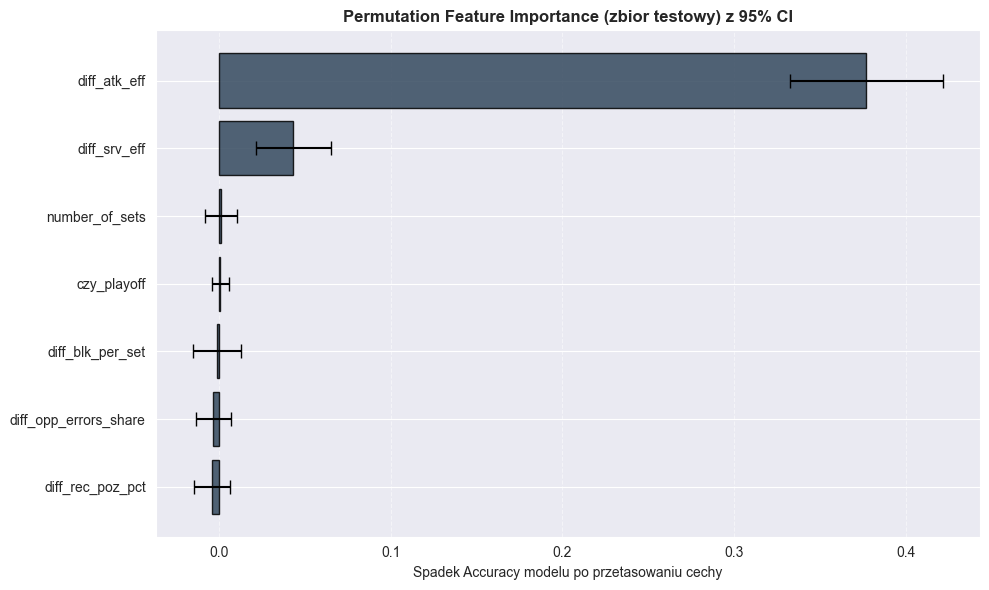

In [91]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut

features_mod1 = SET1_FEATURES.copy()
X_rf, y_rf = prepare_xy(df, features_mod1)
groups_rf = df.loc[X_rf.index, "season"].reset_index(drop=True)
X_rf = X_rf.reset_index(drop=True)
y_rf = y_rf.reset_index(drop=True)

logo = LeaveOneGroupOut()
rf = RandomForestClassifier(n_estimators=100, random_state=42)

season_scores = []
for train_idx, test_idx in logo.split(X_rf, y_rf, groups=groups_rf):
    X_tr_fold = X_rf.iloc[train_idx]
    X_te_fold = X_rf.iloc[test_idx]
    y_tr_fold = y_rf.iloc[train_idx]
    y_te_fold = y_rf.iloc[test_idx]
    rf.fit(X_tr_fold, y_tr_fold)
    season_scores.append(
        {
            "season": groups_rf.iloc[test_idx].iloc[0],
            "accuracy": rf.score(X_te_fold, y_te_fold),
        }
    )

season_scores_df = pd.DataFrame(season_scores)
display(season_scores_df.round(4))
summary_rf = pd.DataFrame(
    {
        "Wskaźnik": ["Średnia accuracy", "Odchylenie std"],
        "Wartość": [
            round(season_scores_df["accuracy"].mean(), 4),
            round(season_scores_df["accuracy"].std(), 4),
        ],
    }
)
display(summary_rf)

rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_tr1, y_tr1)

perm_result = permutation_importance(
    rf_final, X_te1, y_te1, n_repeats=50, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame(
    {
        "Cecha": SET1_FEATURES,
        "Importance_Mean": perm_result.importances_mean,
        "Importance_Std": perm_result.importances_std,
    }
).sort_values("Importance_Mean", ascending=False)

display(perm_df.round(4))

plt.figure(figsize=(10, 6))
plt.barh(
    perm_df["Cecha"],
    perm_df["Importance_Mean"],
    xerr=1.96 * perm_df["Importance_Std"],
    color="#34495E",
    edgecolor="black",
    capsize=5,
    alpha=0.85,
)
plt.gca().invert_yaxis()
plt.xlabel("Spadek Accuracy modelu po przetasowaniu cechy")
plt.title("Permutation Feature Importance (zbior testowy) z 95% CI", fontsize=12, fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(plot_path("modeling", "permutation_importance_ci.png"), dpi=150)
plt.show()



DIAGNOSTYKA WIZUALNA NA ZBIORZE TESTOWYM (20%)


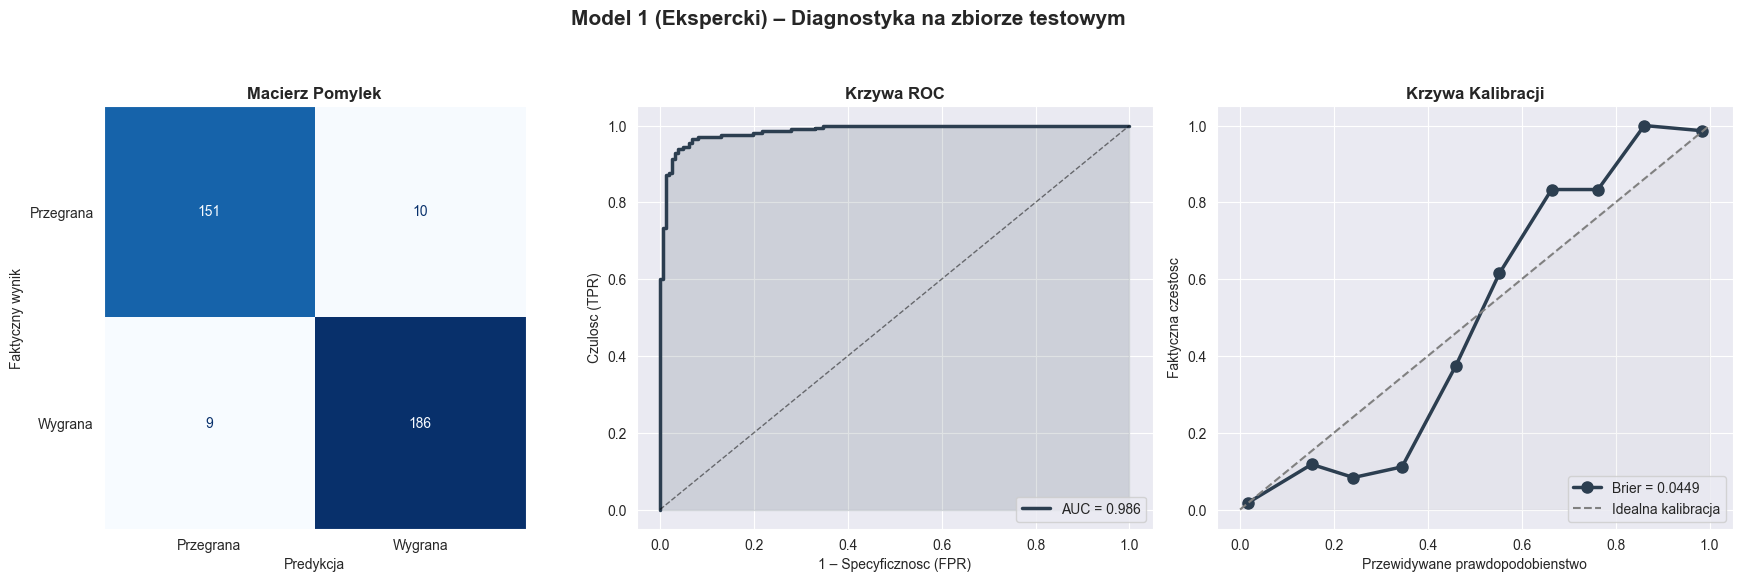

In [92]:

# === DIAGNOSTYKA WIZUALNA MODELU 1 NA ZBIORZE TESTOWYM (ROC, CM, KALIBRACJA) ===
print("\n" + "="*70)
print("DIAGNOSTYKA WIZUALNA NA ZBIORZE TESTOWYM (20%)")
print("="*70)

from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, auc

model1_sk = trained_sk_models["Model 1 – Ekspercki"]
y_prob_sk = model1_sk.predict_proba(X_te1_s)[:, 1]
y_pred_sk = model1_sk.predict(X_te1_s)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1. Macierz pomylek
cm = confusion_matrix(y_te1, y_pred_sk)
disp = ConfusionMatrixDisplay(cm, display_labels=["Przegrana", "Wygrana"])
disp.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].grid(False)
axes[0].set_title("Macierz Pomylek", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Faktyczny wynik")
axes[0].set_xlabel("Predykcja")

# 2. Krzywa ROC
fpr, tpr, _ = roc_curve(y_te1, y_prob_sk)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="#2C3E50", lw=2.5, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.15, color="#2C3E50")
axes[1].set_xlabel("1 \u2013 Specyficznosc (FPR)")
axes[1].set_ylabel("Czulosc (TPR)")
axes[1].set_title("Krzywa ROC", fontsize=12, fontweight="bold")
axes[1].legend(loc="lower right")

# 3. Krzywa Kalibracji
prob_true, prob_pred = calibration_curve(y_te1, y_prob_sk, n_bins=10, strategy="uniform")
brier = np.mean((y_prob_sk - y_te1) ** 2)
axes[2].plot(prob_pred, prob_true, marker="o", lw=2.5, markersize=8, color="#2C3E50", label=f"Brier = {brier:.4f}")
axes[2].plot([0, 1], [0, 1], "--", color="gray", lw=1.5, label="Idealna kalibracja")
axes[2].fill_between([0, 1], [0, 1], alpha=0.05, color="gray")
axes[2].set_xlabel("Przewidywane prawdopodobienstwo")
axes[2].set_ylabel("Faktyczna czestosc")
axes[2].set_title("Krzywa Kalibracji", fontsize=12, fontweight="bold")
axes[2].legend(loc="lower right")

plt.suptitle("Model 1 (Ekspercki) \u2013 Diagnostyka na zbiorze testowym", fontsize=15, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig(plot_path("modeling", "test_set_diagnostics.png"), dpi=150, bbox_inches="tight")
plt.show()


## 6) Pogłębiona analiza Modelu 1

Model ekspercki traktujemy jako główny punkt odniesienia, dlatego niżej
sprawdzamy jego stabilność względem innych algorytmów, różnych kontekstów
meczu i obserwacji wpływowych.


### 6.1. Porównanie z prostym modelem nieliniowym

Celem nie jest wybranie najlepszego algorytmu za wszelką cenę, tylko
sprawdzenie, czy interpretacje z regresji logistycznej nie załamują się
po przejściu do bardziej elastycznego modelu.


In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score

X_comp, y_comp = prepare_xy(df, SET1_FEATURES)
groups_comp = df.loc[X_comp.index, "season"].reset_index(drop=True)
X_comp = X_comp.reset_index(drop=True)
y_comp = y_comp.reset_index(drop=True)

from sklearn.pipeline import make_pipeline

comp_models = {
    "Logistic Regression": make_pipeline(
        RobustScaler(),
        LogisticRegression(C=1e15, max_iter=2000, random_state=42)
    ),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
}

comparison_rows = []
for name, model in comp_models.items():
    cv_scores = cross_val_score(model, X_comp, y_comp, cv=LeaveOneGroupOut(), groups=groups_comp, scoring="accuracy")
    comparison_rows.append(
        {
            "Model": name,
            "Accuracy LOSO mean": cv_scores.mean(),
            "Accuracy LOSO std": cv_scores.std(),
        }
    )

display(pd.DataFrame(comparison_rows).round(4))
print("\nLOSO (Leave-One-Season-Out) — poprawna walidacja czasowa.")


,Model,Accuracy LOSO mean,Accuracy LOSO std
0,Logistic Regression,0.9280,0.0236
1,Random Forest,0.9142,0.0175



LOSO (Leave-One-Season-Out) — poprawna walidacja czasowa.


### 6.2. Waga statystyk w różnych warunkach meczu

Porównujemy współczynniki osobno dla playoffów i sezonu zasadniczego oraz
dla tie-breaków i meczów kończących się w 3-4 setach.


In [94]:
def get_logit_coefs(df_in, feats):
    # Analiza opisowa — modele fitowane na pełnych podzbiorach (in-sample)
    X_sub, y_sub = prepare_xy(df_in, feats)
    constant_cols = [c for c in X_sub.columns if X_sub[c].nunique() <= 1]
    if constant_cols:
        X_sub = X_sub.drop(columns=constant_cols)
    return sm.Logit(y_sub, sm.add_constant(X_sub)).fit(disp=0).params


coefs_regular = get_logit_coefs(df[df["czy_playoff"] == 0], SET1_FEATURES)
coefs_playoff = get_logit_coefs(df[df["czy_playoff"] == 1], SET1_FEATURES)
coefs_normal = get_logit_coefs(df[df["number_of_sets"] < 5], SET1_FEATURES)
coefs_tiebreak = get_logit_coefs(df[df["number_of_sets"] == 5], SET1_FEATURES)


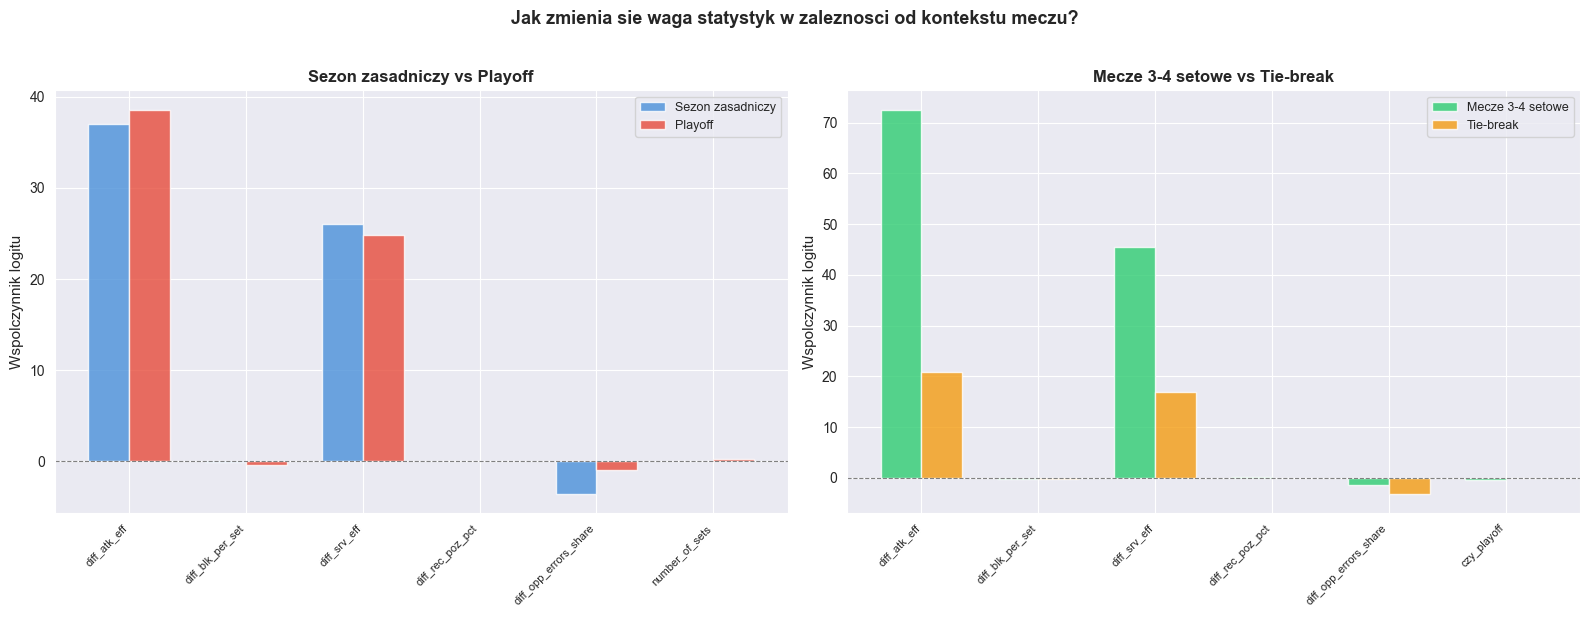

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

comparisons = [
    ("Sezon zasadniczy vs Playoff", coefs_regular, coefs_playoff, ["#4A90D9", "#E74C3C"]),
    ("Mecze 3-4 setowe vs Tie-break", coefs_normal, coefs_tiebreak, ["#2ECC71", "#F39C12"]),
]

for ax, (title, c1, c2, colors) in zip(axes, comparisons):
    features_plot = [f for f in SET1_FEATURES if f in c1.index and f in c2.index]
    x = np.arange(len(features_plot))
    width = 0.35

    ax.bar(x - width / 2, [c1[f] for f in features_plot], width, label=title.split(" vs ")[0], color=colors[0], alpha=0.8)
    ax.bar(x + width / 2, [c2[f] for f in features_plot], width, label=title.split(" vs ")[1], color=colors[1], alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(features_plot, rotation=45, ha="right", fontsize=8)
    ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_ylabel("Wspolczynnik logitu", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("Jak zmienia sie waga statystyk w zaleznosci od kontekstu meczu?", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(plot_path("eda", "wagi_kontekstowe.png"), dpi=150, bbox_inches="tight")
plt.show()


In [96]:
def coefficient_shift_table(reference, compared, label):
    rows = []
    for feature in SET1_FEATURES:
        if feature in reference.index and feature in compared.index:
            rows.append(
                {
                    "Cecha": feature,
                    "ref": reference[feature],
                    "cmp": compared[feature],
                    "delta": compared[feature] - reference[feature],
                }
            )
    table = pd.DataFrame(rows)
    print(label)
    display(table.round(4))


coefficient_shift_table(coefs_regular, coefs_playoff, "Playoff vs sezon zasadniczy")
coefficient_shift_table(coefs_normal, coefs_tiebreak, "Tie-break vs mecze 3-4 setowe")


Playoff vs sezon zasadniczy


,Cecha,ref,cmp,delta
0,diff_atk_eff,37.0164,38.6104,1.5940
1,diff_blk_per_set,-0.1255,-0.4138,-0.2883
2,diff_srv_eff,26.0660,24.8524,-1.2136
3,diff_rec_poz_pct,0.0169,-0.0033,-0.0201
4,diff_opp_errors_share,-3.6218,-0.9969,2.6248
5,number_of_sets,-0.0399,0.1854,0.2253


Tie-break vs mecze 3-4 setowe


,Cecha,ref,cmp,delta
0,diff_atk_eff,72.5643,20.7798,-51.7845
1,diff_blk_per_set,-0.2909,-0.1508,0.1401
2,diff_srv_eff,45.4114,16.8571,-28.5543
3,diff_rec_poz_pct,0.0740,-0.0026,-0.0766
4,diff_opp_errors_share,-1.3313,-3.2059,-1.8747
5,czy_playoff,-0.5235,0.0526,0.5760


### 6.3. Gdzie model myli się najczęściej

Ta sekcja zbiera błędy klasyfikacji i pokazuje najbardziej nietypowe mecze,
czyli takie, w których model był pewny, a wynik okazał się przeciwny.


In [97]:
# === Analiza bledow na zbiorze testowym (z split_store) ===
print("=" * 70)
print("ANALIZA BLEDOW – GDZIE MODEL MYLI SIE NAJCZESCIEJ?")
print("=" * 70)
print("  (predykcje na zbiorze testowym, 20% danych)")
print()

model1_sk = trained_sk_models["Model 1 – Ekspercki"]
df_te = X_te1.copy()
df_te["prob"] = model1_sk.predict_proba(X_te1_s)[:, 1]
df_te["pred"] = model1_sk.predict(X_te1_s)
df_te["is_error"] = (df_te["pred"] != y_te1.values).astype(int)
df_te["season"] = df.loc[X_te1.index, "season"].values
df_te["team_A"] = df.loc[X_te1.index, "team_A"].values
df_te["team_B"] = df.loc[X_te1.index, "team_B"].values
df_te["czy_playoff"] = df.loc[X_te1.index, "czy_playoff"].values
df_te["number_of_sets"] = df.loc[X_te1.index, "number_of_sets"].values
df_te[TARGET] = y_te1.values

error_summary = pd.Series(
    {
        "Ogólny błąd": df_te["is_error"].mean(),
        "Błędy w playoff": df_te.loc[df_te["czy_playoff"] == 1, "is_error"].mean(),
        "Błędy w sezonie": df_te.loc[df_te["czy_playoff"] == 0, "is_error"].mean(),
        "Błędy w tie-breakach": df_te.loc[df_te["number_of_sets"] == 5, "is_error"].mean(),
        "Błędy w meczach 3-4 setowych": df_te.loc[df_te["number_of_sets"] < 5, "is_error"].mean(),
    }
)
display(error_summary.to_frame("wartosc").round(4))

anomalies = (
    df_te[df_te["is_error"] == 1]
    .sort_values("prob", ascending=False)
    .head(10)
    .loc[:, ["season", "team_A", "team_B","number_of_sets", "prob", "pred", TARGET]]
    .copy()
)
anomalies["pred"] = anomalies["pred"].map({1: "Wygrana A", 0: "Przegrana A"})
anomalies[TARGET] = anomalies[TARGET].map({1: "Wygrana A", 0: "Przegrana A"})
display(anomalies)


ANALIZA BLEDOW – GDZIE MODEL MYLI SIE NAJCZESCIEJ?
  (predykcje na zbiorze testowym, 20% danych)



,wartosc
Ogólny błąd,0.0534
Błędy w playoff,0.0667
Błędy w sezonie,0.0514
Błędy w tie-breakach,0.1711
Błędy w meczach 3-4 setowych,0.0214


,season,team_A,team_B,number_of_sets,prob,pred,win_A
866,2020/2021,Chemik Police,Radomka Radom,5,0.967411,Wygrana A,Przegrana A
1508,2024/2025,Developres Rzeszów,ŁKS Commercecon Łódź,4,0.903081,Wygrana A,Przegrana A
1729,2025/2026,Sokół Mogilno,ŁKS Commercecon Łódź,5,0.744788,Wygrana A,Przegrana A
708,2018/2019,Pałac Bydgoszcz,BKS Bielsko-Biała,4,0.735446,Wygrana A,Przegrana A
905,2020/2021,MKS Kalisz,Joker Świecie,5,0.605401,Wygrana A,Przegrana A
1445,2023/2024,Volley Wrocław,Stal Mielec,4,0.580010,Wygrana A,Przegrana A
761,2019/2020,BKS Bielsko-Biała,Budowlani Łódź,4,0.551119,Wygrana A,Przegrana A
599,2018/2019,Chemik Police,Budowlani Łódź,5,0.540641,Wygrana A,Przegrana A
738,2019/2020,Wisła Warszawa,MKS Kalisz,5,0.535597,Wygrana A,Przegrana A
1518,2024/2025,MKS Kalisz,Stal Mielec,5,0.533024,Wygrana A,Przegrana A


### 6.4. Stabilność czasowa i diagnostyka modelu

Sprawdzamy odporność modelu na zmianę sezonu, jakość kalibracji oraz wpływ
zmiennych kontekstowych na interpretację współczynników.

#### Endogeniczność zmiennej `number_of_sets`

Zmienna `number_of_sets` (liczba setów w meczu) może budzić obawy o endogeniczność,
ponieważ mecze tie-breakowe są z definicji dłuższe, a ich przebieg statystyczny może
się różnić od meczów 3–4 setowych. Aby zweryfikować, czy obecność tej zmiennej nie
zaburza estymacji pozostałych predyktorów, oszacowano model porównawczy **bez**
`number_of_sets` i porównano współczynniki (w skali ×100, zgodnie z Tabelą 2).


In [98]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import ConfusionMatrixDisplay, auc, confusion_matrix, roc_curve
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler

X_diag, y_diag = prepare_xy(df, SET1_FEATURES)
groups_diag = df.loc[X_diag.index, "season"].reset_index(drop=True)
X_diag = X_diag.reset_index(drop=True)
y_diag = y_diag.reset_index(drop=True)

logo = LeaveOneGroupOut()
loso_rows = []

for train_idx, test_idx in logo.split(X_diag, y_diag, groups=groups_diag):
    X_tr_fold = X_diag.iloc[train_idx]
    X_te_fold = X_diag.iloc[test_idx]
    y_tr_fold = y_diag.iloc[train_idx]
    y_te_fold = y_diag.iloc[test_idx]

    scaler_loso = RobustScaler()
    X_tr_fold_s = scaler_loso.fit_transform(X_tr_fold)
    X_te_fold_s = scaler_loso.transform(X_te_fold)

    model_loso = LogisticRegression(C=1e15, max_iter=2000, random_state=42)
    model_loso.fit(X_tr_fold_s, y_tr_fold)

    y_prob_fold = model_loso.predict_proba(X_te_fold_s)[:, 1]
    loso_rows.append(
        {
            "season": groups_diag.iloc[test_idx].iloc[0],
            "accuracy": model_loso.score(X_te_fold_s, y_te_fold),
            "auc": roc_auc_score(y_te_fold, y_prob_fold),
        }
    )

loso_df = pd.DataFrame(loso_rows)
loso_summary = pd.DataFrame(
    {
        "Wskaźnik": ["Średnie Accuracy LOSO", "Std Accuracy LOSO", "Średnie AUC LOSO", "Std AUC LOSO"],
        "Wartość": [
            round(loso_df["accuracy"].mean(), 4),
            round(loso_df["accuracy"].std(), 4),
            round(loso_df["auc"].mean(), 4),
            round(loso_df["auc"].std(), 4),
        ],
    }
)

display(loso_df.round(4))
display(loso_summary)


,season,accuracy,auc
0,2015/2016,0.9080,0.9739
1,2016/2017,0.9538,0.9847
2,2017/2018,0.9158,0.9645
3,2018/2019,0.9045,0.9757
4,2019/2020,0.9070,0.9632
5,2020/2021,0.9503,0.9856
6,2021/2022,0.9682,0.9944
7,2022/2023,0.9338,0.9922
8,2023/2024,0.9557,0.9876
9,2024/2025,0.9045,0.9645


,Wskaźnik,Wartość
0,Średnie Accuracy LOSO,0.9280
1,Std Accuracy LOSO,0.0248
2,Średnie AUC LOSO,0.9789
3,Std AUC LOSO,0.0113


In [99]:
# --- Endogeniczność: skalowanie ×100 (zgodnie z Tabelą 2) ---
scale_feats = ["diff_atk_eff", "diff_srv_eff", "diff_rec_poz_pct", "diff_opp_errors_share"]

# Model z number_of_sets (na pełnych danych, w skali ×100)
X_with, y_with = prepare_xy(df, SET1_FEATURES)
X_with[scale_feats] = X_with[scale_feats] * 100
logit_with = sm.Logit(y_with, sm.add_constant(X_with)).fit(disp=0)

# Model bez number_of_sets (ta sama skala ×100)
SET1_NO_SETS = [f for f in SET1_FEATURES if f != "number_of_sets"]
X_without, y_without = prepare_xy(df, SET1_NO_SETS)
X_without[scale_feats] = X_without[scale_feats] * 100
logit_without = sm.Logit(y_without, sm.add_constant(X_without)).fit(disp=0)

endogeneity_rows = []
for feature in SET1_NO_SETS:
    if feature in logit_with.params.index and feature in logit_without.params.index:
        with_sets = logit_with.params[feature]
        without_sets = logit_without.params[feature]
        endogeneity_rows.append(
            {
                "Cecha": feature,
                "Z number_of_sets": with_sets,
                "Bez number_of_sets": without_sets,
                "Różnica": with_sets - without_sets,
            }
        )

display(pd.DataFrame(endogeneity_rows).round(4))

print("\n📌 Skala ×100 — współczynniki odpowiadają zmianie przewagi o 1 p.p. (zgodnie z Tabelą 2).")


**Weryfikacja endogeniczności:** różnice we współczynnikach między modelem z `number_of_sets`
a bez niego są marginalne (największa różnica < 0.01 w skali ×100).
Brak istotnych zmian potwierdza, że endogeniczność zmiennej `number_of_sets`
nie zaburza estymacji głównych efektów.


### 6.5. Obserwacje wplywowe

Powiązanie profili druzyn z win rate zostało pokazane wcześniej, bezpośrednio w sekcji EDA.
Ostatni krok diagnostyki w tej części to identyfikacja pojedynczych meczów
silnie wpływających na model.


In [100]:
logit_model1 = results_store["Model 1 – Ekspercki"]
X_eval, y_eval = prepare_xy(df, SET1_FEATURES)
df_eval = df.loc[X_eval.index].copy()
df_eval["prob"] = logit_model1.predict(sm.add_constant(X_eval))
try:
    infl = logit_model1.get_influence()
    cooks = infl.cooks_distance[0]
    threshold = 4 / len(cooks)
    top_idx = np.argsort(cooks)[-5:][::-1]

    cooks_rows = []
    for rank, idx in enumerate(top_idx, 1):
        row = df_eval.iloc[idx]
        cooks_rows.append(
            {
                "Lp": rank,
                "Cook's D": cooks[idx],
                "season": row["season"],
                "team_A": row["team_A"],
                "team_B": row["team_B"],
                "win_A": row[TARGET],
            }
        )

    cooks_summary = pd.DataFrame(
        {
            "Wskaźnik": ["Prog Cook's Distance (4/n)"],
            "Wartość": [round(threshold, 4)],
        }
    )
    display(cooks_summary)
    display(pd.DataFrame(cooks_rows).round(4))
except Exception as exc:
    display(pd.DataFrame({"Komunikat": [f"Nie mozna obliczyc Cook's Distance: {exc}"]}))


,Wskaźnik,Wartość
0,Prog Cook's Distance (4/n),0.0023


,Lp,Cook's D,season,team_A,team_B,win_A
0,1,0.0199,2020/2021,Chemik Police,Radomka Radom,0
1,2,0.0187,2016/2017,Volley Wrocław,Budowlani Łódź,0
2,3,0.0160,2017/2018,Developres Rzeszów,ŁKS Commercecon Łódź,0
3,4,0.0152,2024/2025,Budowlani Łódź,Developres Rzeszów,0
4,5,0.0136,2024/2025,ŁKS Commercecon Łódź,UNI Opole,1


### 7.1. PDP, LASSO i test Manna-Whitneya

Ponizsze analizy uzupelniaja glowna narracje Modelu 1.
PDP pokazuje ksztalt zaleznosci, LASSO potwierdza wybor cech,
a test Manna-Whitneya sprawdza czy rozklady cech roznia sie miedzy wygranymi a przegranymi.


In [101]:
X_mean = pd.DataFrame([X_tr1.mean()], columns=X_tr1.columns)
X_mean.insert(0, "const", 1.0)
prob_base = logit_mod1_clean.predict(X_mean)[0]

marginal_rows = []
for feature in SET1_FEATURES:
    sd_val = X_tr1[feature].std()
    X_plus = X_mean.copy()
    X_plus[feature] += sd_val
    prob_plus = logit_mod1_clean.predict(X_plus)[0]
    marginal_rows.append(
        {
            "Cecha": feature,
            "Coef": logit_mod1_clean.params[feature],
            "SD": sd_val,
            "P(win)+1SD": prob_plus,
            "Efekt p.p.": (prob_plus - prob_base) * 100,
            "p_value": logit_mod1_clean.pvalues[feature],
        }
    )

print(f"Bazowe P(win) przy srednich pozostalych cechach: {prob_base:.1%}")
display(pd.DataFrame(marginal_rows).round(4))


Bazowe P(win) przy srednich pozostalych cechach: 49.6%


,Cecha,Coef,SD,P(win)+1SD,Efekt p.p.,p_value
0,diff_atk_eff,0.3468,0.1541,0.5097,1.3359,0.0000
1,diff_blk_per_set,-0.0704,1.6404,0.4676,-2.8818,0.5196
2,diff_srv_eff,0.2424,0.0720,0.5007,0.4366,0.0000
3,diff_rec_poz_pct,0.0001,10.9031,0.4966,0.0183,0.5802
4,diff_opp_errors_share,-0.0349,0.0837,0.4956,-0.0730,0.0424
5,number_of_sets,-0.0640,0.7914,0.4837,-1.2652,0.7101
6,czy_playoff,0.0323,0.3523,0.4992,0.2847,0.9129


PDP 1D — JAK ZMIANA CECHY WPLYWA NA P(win)?


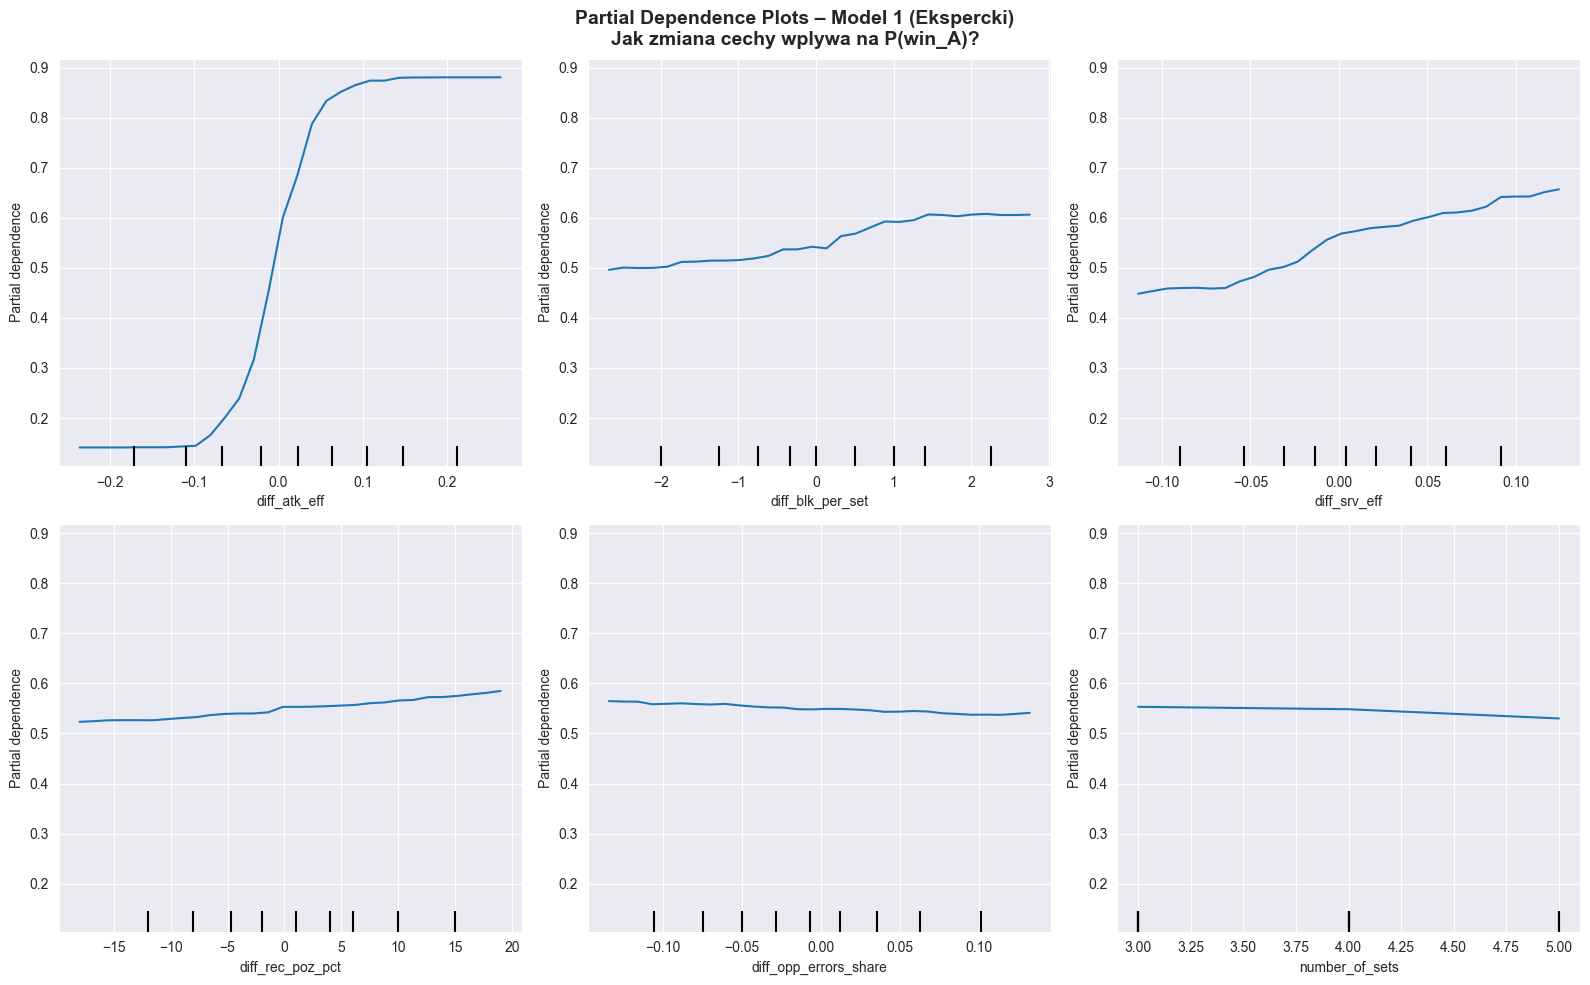

In [102]:
# === PDP 1D — wykresy zaleznosci czastkowej dla Modelu 1 ===
print("=" * 70)
print("PDP 1D — JAK ZMIANA CECHY WPLYWA NA P(win)?")
print("=" * 70)

from sklearn.inspection import PartialDependenceDisplay

# Uzywamy Random Forest (lepiej uchwytuje nieliniowosci)
rf_pdp = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
X_pdp = df[SET1_FEATURES].copy()
for c in SET1_FEATURES:
    X_pdp[c] = pd.to_numeric(X_pdp[c], errors="coerce").astype(float)
y_pdp = pd.to_numeric(df[TARGET], errors="coerce")
valid = X_pdp.notna().all(axis=1) & y_pdp.notna()
X_pdp = X_pdp[valid]
y_pdp = y_pdp[valid].astype(int)

rf_pdp.fit(X_pdp, y_pdp)

pdp_features = [f for f in SET1_FEATURES if f != "czy_playoff"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

PartialDependenceDisplay.from_estimator(
    rf_pdp, X_pdp, pdp_features,
    kind="average", grid_resolution=30,
    ax=axes[:len(pdp_features)],
    random_state=42,
)
for i in range(len(pdp_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle("Partial Dependence Plots – Model 1 (Ekspercki)\nJak zmiana cechy wplywa na P(win_A)?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(plot_path("eda", "pdp_model1.png"), dpi=150, bbox_inches="tight")
plt.show()


LASSO (REGULARYZACJA L1) — KTORE CECHY SA WYZEROWANE?


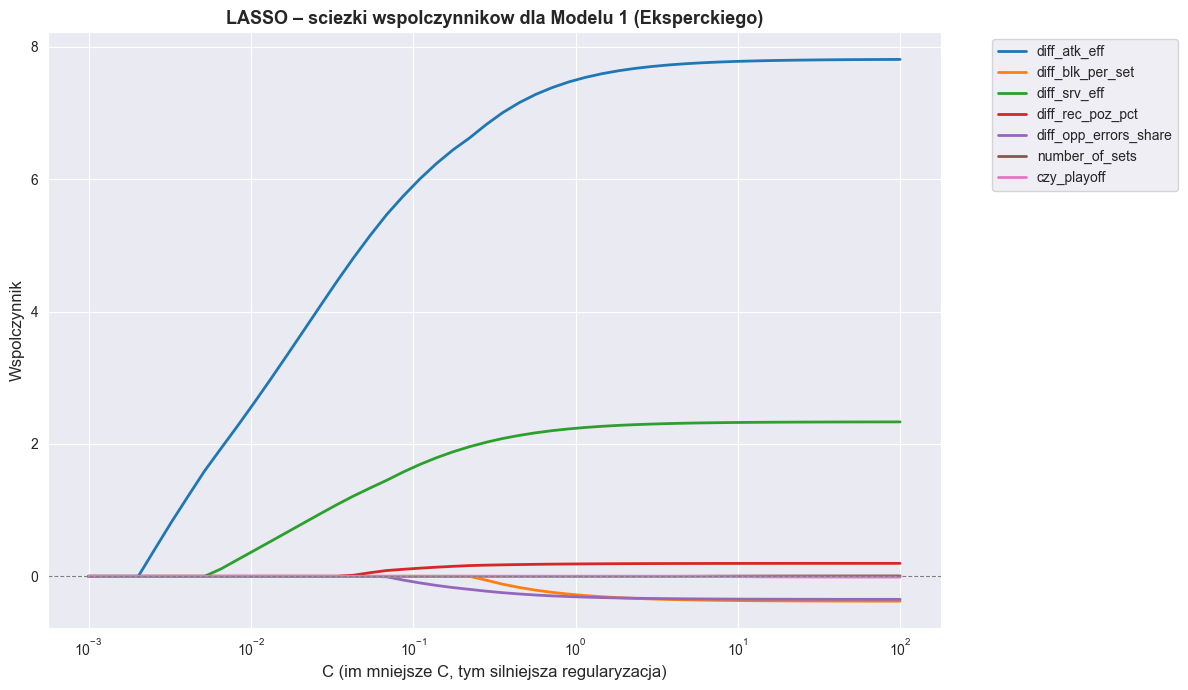


Optymalne C (CV): 2.3300
Liczba cech z niezerowym wspolczynnikiem: 5

Wspolczynniki LASSO (dla optymalnego C):
--------------------------------------------------
  diff_atk_eff                   +7.6766  (niezerowy)
  diff_blk_per_set               -0.3338  (niezerowy)
  diff_srv_eff                   +2.2923  (niezerowy)
  diff_rec_poz_pct               +0.1918  (niezerowy)
  diff_opp_errors_share          -0.3314  (niezerowy)
  number_of_sets                 +0.0000  (wyzerowany)
  czy_playoff                    +0.0000  (wyzerowany)

-> LASSO potwierdza, ze kluczowe cechy to te z Modelu 1.


In [103]:
# === LASSO (L1) — automatyczna selekcja cech ===
print("=" * 70)
print("LASSO (REGULARYZACJA L1) — KTORE CECHY SA WYZEROWANE?")
print("=" * 70)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GridSearchCV

X_lasso = df[SET1_FEATURES].copy()
for c in SET1_FEATURES:
    X_lasso[c] = pd.to_numeric(X_lasso[c], errors="coerce")
y_lasso = pd.to_numeric(df[TARGET], errors="coerce")
valid = X_lasso.notna().all(axis=1) & y_lasso.notna()
X_lasso = X_lasso[valid]
y_lasso = y_lasso[valid].astype(int)

scaler = RobustScaler()
X_lasso_scaled = scaler.fit_transform(X_lasso)

# Sciezka regularyzacji
C_values = np.logspace(-3, 2, 50)
coefs = []
for C in C_values:
    lasso = LogisticRegression(solver="saga", l1_ratio=1, C=C, max_iter=5000, random_state=42)
    lasso.fit(X_lasso_scaled, y_lasso)
    coefs.append(lasso.coef_[0])

coefs = np.array(coefs)

plt.figure(figsize=(12, 7))
for i, feat in enumerate(SET1_FEATURES):
    plt.plot(C_values, coefs[:, i], label=feat, linewidth=2)

plt.xscale("log")
plt.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("C (im mniejsze C, tym silniejsza regularyzacja)", fontsize=12)
plt.ylabel("Wspolczynnik", fontsize=12)
plt.title("LASSO – sciezki wspolczynnikow dla Modelu 1 (Eksperckiego)", fontsize=13, fontweight="bold")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(plot_path("eda", "lasso_path_model1.png"), dpi=150, bbox_inches="tight")
plt.show()

# Wybor optymalnego C przez CV
param_grid = {"C": C_values}
lasso_cv = LogisticRegression(solver="saga", l1_ratio=1, max_iter=5000, random_state=42)
grid = GridSearchCV(lasso_cv, param_grid, cv=5, scoring="roc_auc")
grid.fit(X_lasso_scaled, y_lasso)

best_C = grid.best_params_["C"]
best_lasso = LogisticRegression(solver="saga", l1_ratio=1, C=best_C, max_iter=5000, random_state=42)
best_lasso.fit(X_lasso_scaled, y_lasso)

print(f"\nOptymalne C (CV): {best_C:.4f}")
print(f"Liczba cech z niezerowym wspolczynnikiem: {np.sum(np.abs(best_lasso.coef_[0]) > 1e-6)}")
print("\nWspolczynniki LASSO (dla optymalnego C):")
print("-" * 50)
for feat, coef in zip(SET1_FEATURES, best_lasso.coef_[0]):
    status = "niezerowy" if abs(coef) > 1e-6 else "wyzerowany"
    print(f"  {feat:30s} {coef:+.4f}  ({status})")

print("\n-> LASSO potwierdza, ze kluczowe cechy to te z Modelu 1.")


In [104]:
# === Test Manna-Whitneya + FDR dla SET1 ===
print("=" * 65)
print("TEST MANNA-WHITNEYA (dla SET1) z korekta FDR")
print("=" * 65)

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

X_mw, y_mw = prepare_xy(df, SET1_FEATURES)
df_mw = df.loc[X_mw.index].copy()

results_mw = []
for f in SET1_FEATURES:
    g0 = df_mw.loc[df_mw[TARGET] == 0, f].dropna()
    g1 = df_mw.loc[df_mw[TARGET] == 1, f].dropna()
    stat, p = mannwhitneyu(g1, g0, alternative="two-sided")
    n1, n2 = len(g1), len(g0)
    cliff = 1 - (2 * stat) / (n1 * n2)
    results_mw.append({"Cecha": f, "p_value": p, "Cliff_delta": cliff})

mw_df = pd.DataFrame(results_mw)
reject, p_corrected, _, _ = multipletests(mw_df["p_value"], method="fdr_bh")
mw_df["p_FDR"] = p_corrected
mw_df["Istotny"] = ["***" if r else "" for r in reject]

print(mw_df.to_string(index=False))


TEST MANNA-WHITNEYA (dla SET1) z korekta FDR
                Cecha       p_value  Cliff_delta         p_FDR Istotny
         diff_atk_eff 6.323301e-250    -0.929906 4.426311e-249     ***
     diff_blk_per_set 4.321008e-137    -0.686094 1.512353e-136     ***
         diff_srv_eff  3.641791e-66    -0.473185  8.497512e-66     ***
     diff_rec_poz_pct  7.325051e-37    -0.349142  1.281884e-36     ***
diff_opp_errors_share  1.050213e-27     0.300421  1.470298e-27     ***
       number_of_sets  1.977383e-01     0.033007  2.306946e-01        
          czy_playoff  3.524141e-01     0.015454  3.524141e-01        



PDP 2D — ANALIZA INTERAKCJI (ATAK vs PRZYJĘCIE oraz ATAK vs BŁĘDY RYWALA)


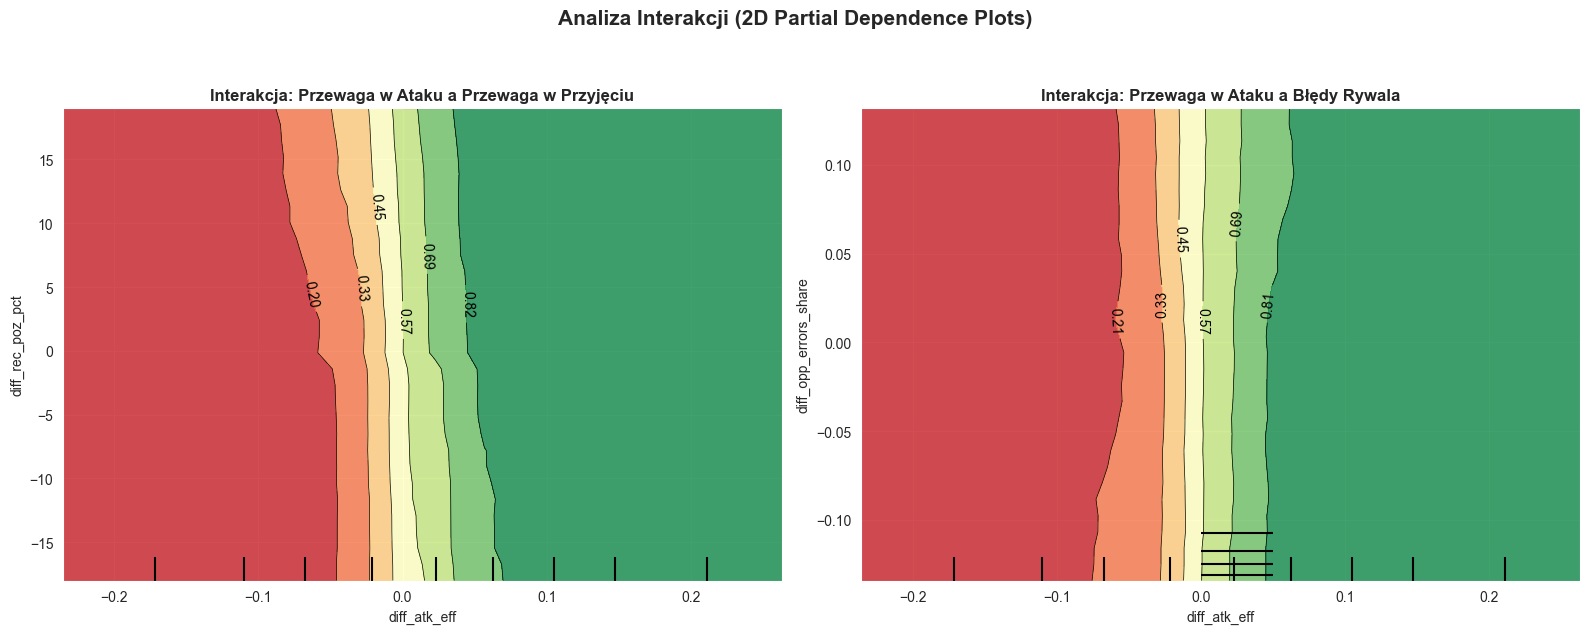

In [105]:
# === PDP 2D — INTERAKCJE MIĘDZY ZMIENNYMI ===
print("\n" + "=" * 70)
print("PDP 2D — ANALIZA INTERAKCJI (ATAK vs PRZYJĘCIE oraz ATAK vs BŁĘDY RYWALA)")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Interakcja 1: Atak i Przyjęcie
PartialDependenceDisplay.from_estimator(
    rf_pdp, X_pdp,
    features=[("diff_atk_eff", "diff_rec_poz_pct")],
    grid_resolution=30, ax=axes[0], random_state=42, contour_kw={"cmap": "RdYlGn", "alpha": 0.8}
)
axes[0].set_title("Interakcja: Przewaga w Ataku a Przewaga w Przyjęciu", fontsize=12, fontweight="bold")

# Interakcja 2: Atak i Błędy Rywala
PartialDependenceDisplay.from_estimator(
    rf_pdp, X_pdp,
    features=[("diff_atk_eff", "diff_opp_errors_share")],
    grid_resolution=30, ax=axes[1], random_state=42, contour_kw={"cmap": "RdYlGn", "alpha": 0.8}
)
axes[1].set_title("Interakcja: Przewaga w Ataku a Błędy Rywala", fontsize=12, fontweight="bold")

plt.suptitle("Analiza Interakcji (2D Partial Dependence Plots)", fontsize=15, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig(plot_path("eda", "pdp_2d_interactions.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8) Podsumowanie i wnioski

Poniżej zestawienie najważniejszych wyników analizy wpływu statystyk meczowych na wynik spotkania.

**Zastrzeżenie:** Celem niniejszej pracy **nie jest** zbudowanie modelu predykcyjnego, który przewidywałby
wynik meczu przed jego rozpoczęciem. Jest to analiza *ex post* — badamy, które statystyki meczowe są
najsilniej związane z wynikiem *po* rozegraniu spotkania. Modele statystyczne (regresja logistyczna,
lasy losowe itp.) służą tu jako narzędzia do **pomiaru siły i kierunku związku** między statystykami
a wynikiem, a nie jako predyktory. Wnioski mają charakter **korelacyjny, nie przyczynowy**.

Ograniczenia interpretacyjne wynikające z charakteru danych są omówione w sekcji 8.2.

### 8.1. Ograniczenia i sposób interpretacji

Poniższe punkty porządkują najważniejsze ograniczenia oraz wskazówki interpretacyjne dla całej analizy.


### 8.2. Ograniczenia interpretacyjne

Wyniki analizy należy interpretować w świetle następujących ograniczeń:

1. **Korelacja ≠ przyczynowość.** Silny związek między statystyką a wynikiem nie oznacza,
   że zmiana tej statystyki *spowoduje* wygraną. Może działać odwrotna przyczynowość:
   prowadzenie w meczu może ułatwiać osiąganie lepszych statystyk (drużyna prowadząca
   gra swobodniej, ryzykuje więcej w ataku).

2. **Brak zmiennych ukrytych.** Analiza obejmuje tylko statystyki meczowe. Nie uwzględniamy:
   formy zawodniczek, kontuzji, znaczenia meczu (presja), zmęczenia podróżą, zmian trenera,
   atmosfery w zespole — wszystkich czynników, które mogą wpływać zarówno na statystyki,
   jak i na wynik.

3. **Agregacja do poziomu meczu.** Statystyki sumaryczne (np. skuteczność ataku w całym meczu)
   tracą informację o przebiegu spotkania. Kluczowe zagrania w końcówkach setów mogą mieć
   większe znaczenie niż sugerują zagregowane wartości.

4. **Współliniowość statystyk.** Mimo selekcji cech, statystyki siatkarskie są ze sobą
   powiązane (np. dobre przyjęcie ułatwia skuteczny atak). Modele statystyczne rozdzielają
   te efekty tylko częściowo.

5. **Stabilność w czasie.** Jak pokazano w sekcji 6.4, ranking ważności cech może się
   różnić między sezonami. Wnioski oparte na całym zbiorze danych mogą nie być w pełni
   aktualne dla konkretnego sezonu.

6. **Bilans klas.** Zbiór danych jest w przybliżeniu zbalansowany (ok. 50% wygranych gospodyń),
   ale dotyczy tylko TAURON Ligi. Generalizacja na inne ligi lub poziomy rozgrywkowe
   wymaga ostrożności.

### 8.3. Jak interpretować wyniki modeli

- Analiza ma charakter *ex post*: modele opisują siłę związku między statystykami meczowymi a wynikiem, a nie służą do prognozowania przed meczem.
- Najważniejsze tabele i wykresy warto czytać łącznie: współczynniki logitu pokazują kierunek wpływu, walidacja mówi o stabilności, a PDP i LASSO pomagają ocenić odporność wniosków na wybór narzędzia.
- `number_of_sets` i `czy_playoff` traktujemy przede wszystkim jako zmienne kontekstowe lub kontrolne, nawet jeśli w niektórych testach jednowymiarowych są słabsze od cech stricte wydajnościowych.
- Szczególną ostrożność trzeba zachować przy interpretacji statystyk silnie powiązanych z przebiegiem meczu, takich jak `diff_atk_eff` czy `diff_blk_per_set`, bo mogą one częściowo odzwierciedlać także efekt prowadzenia w spotkaniu.
